Mini-Project: Predicting Heart Disease

# Introduction

Nous allons construire un pipeline complet pour prédire la présence d'une cardiopathie (heart disease) à l’aide de données médicales de patients (âge, tension, cholestérol, etc.), et cela en utilisant des algorithmes de classification supervisée. Le modèle de base exigé est la régression logistique, mais on ira bien sûr aller plus loin.

# Cadrage et Compréhension du Besoin (Phase 1 du Roadmap ML)

Avant de plonger dans le code, nous analysons les éléments clés du projet selon une approche "Roadmap Projet Machine Learning".

1. Clarification de l'Objectif et Problème ML

* L'objectif est d'identifier si un patient est atteint de cardiopathie ou non, en se basant sur diverses caractéristiques médicales. C'est un problème de diagnostic prédictif.

* Il s'agit clairement d'un problème de classification supervisée. Nous avons des données d'entrée (caractéristiques médicales) et une variable cible à prédire (présence ou absence de cardiopathie).

* Variable Cible

> Le dataset contient une colonne num. D'après l'extrait max 4.000000, num semble être la variable indiquant la présence et la sévérité de la maladie. Souvent, dans les datasets UCI Heart Disease, 0 signifie "absence de maladie cardiaque" et 1, 2, 3, 4 indiquent différents niveaux de présence/sévérité de la maladie.

> Proposition de variable cible : la colonne num sera notre variable cible principale.

>> Approche Binaire : pour prédire la simple présence ou absence de cardiopathie, nous transformerons num. Si num = 0, le patient n'a pas de maladie (classe 0). Si num > 0 (donc 1, 2, 3, ou 4), le patient a une maladie (classe 1). C'est l'approche la plus courante pour un diagnostic simple "oui/non".

>> Approche Multi-classes : pour prédire les différents niveaux de sévérité de la cardiopathie, nous utiliserons num directement avec ses valeurs originales (0, 1, 2, 3, 4). Cela permettra de faire des diagnostics plus nuancés.


* Définition du Succès (Métriques)

> Puisqu'il s'agit d'un problème de classification, les métriques clés seront :

>> Accuracy (Précision globale) : proportion des prédictions correctes. Utile pour une vue d'ensemble, mais peut être trompeuse si les classes sont déséquilibrées.

>> Precision (Précision) : parmi les prédictions positives (maladie détectée), quelle proportion était réellement positive ? Important pour minimiser les faux positifs (diagnostics erronés).

>> Recall (Rappel/Sensibilité) : parmi tous les cas positifs réels (maladie présente), quelle proportion a été correctement détectée ? Crucial pour minimiser les faux négatifs (cas de maladie manqués).

>> F1-Score : Moyenne harmonique de la précision et du rappel. Un bon équilibre entre les deux, utile quand on cherche à minimiser les deux types d'erreurs.

>> Matrice de Confusion : pour visualiser les vrais positifs/négatifs et les faux positifs/négatifs.

>> Courbe ROC / AUC (Area Under the Curve) : très pertinente pour évaluer la capacité du modèle à distinguer les classes, surtout si les classes sont déséquilibrées.


* Usages et Contraintes

> Usage : aide au diagnostic médical, dépistage précoce, identification de populations à risque.

> Contraintes :

>> Fiabilité/Confiance : dans le domaine de la santé, la fiabilité est primordiale. Les faux négatifs (patient malade non détecté) peuvent avoir des conséquences graves. Le Recall sera donc probablement une métrique très importante, voire prioritaire.

>> Interprétabilité : comprendre pourquoi le modèle prend certaines décisions est crucial pour les professionnels de santé.

>> Données Sensibles : les données médicales sont des données personnelles sensibles (RGPD). La gestion de la confidentialité sera essentielle.

>> Biais : s'assurer que le modèle ne présente pas de biais (par exemple, moins performant pour certains groupes d'âge, de sexe, ou d'origine ethnique, même si ces dernières infos ne sont pas dans le dataset, c'est une considération générale).


2. Pertinence du ML

> Peut-on/veut-on résoudre sans ML ? La cardiopathie est complexe, avec de nombreux facteurs interdépendants. Des règles métier simples seraient très limitées et peu précises. Le ML est donc un outil très approprié pour capturer ces interactions complexes et faire des prédictions nuancées.


# Collecte & Accès aux Données (Phase 2 du Roadmap ML)

* Source : "Heart Disease UCI dataset".

> L'ensemble de données UCI sur les maladies cardiaques provient du référentiel d'apprentissage automatique de l'UCI. Il a été collecté en 1988 dans quatre villes : Cleveland, la Hongrie, la Suisse et Long Beach. Il comprend 920 cas de personnes atteintes ou non de maladies cardiovasculaires (MCV), avec 76 attributs pour chaque cas.

> L'ensemble de données a été compilé par des chercheurs tels qu'Andras Janosi, William Steinbrunn, Matthias Pfisterer et Robert Detrano, entre autres.

> L'ensemble de données est sous licence Creative Commons Attribution 4.0 International (CC BY 4.0).

* Accès : le dataset est fourni sous forme d'un fichier CSV à charger.

* Glossaire (cf. plus bas) : pour une meilleure compréhension de la problématique globale (Médical / ML / Impact Business)

# Plan d'Action Pas-à-Pas Détaillé

L'analyse est structurée comme suit


# Étape 1 : Chargement et Création de la Cible Binaire

* Chargement du dataset Heart Disease UCI.

* Création de la variable cible has_heart_disease.


# Étape 2 : Exploration des Données (EDA - Exploratory Data Analysis)

* Aperçu général du DataFrame info(), describe(), head().

* Vérification des valeurs manquantes.

* Traitement initial des valeurs aberrantes codées en 0 (pour trestbps, chol).

* Analyse des Corrélations (Matrice de corrélation des features numériques avec la cible).

* Analyse des distributions des variables numériques (histogrammes).

* Analyse des distributions des variables catégorielles (diagrammes en barres).


# Étape 3 : Pré-traitement des Données

* Suppression des colonnes non pertinentes ou trop manquantes.

* Identification des colonnes numériques et catégorielles restantes.

* Création des Pipelines de Pré-traitement (Imputation, Scaling, Encodage).

* Application du pré-traitement (génération de X_processed et y).


# Étape 4 : Modélisation

* Division du Dataset en ensembles d'entraînement et de test (X_train, X_test, y_train, y_test).

* Entraînement des différents modèles (Régression Logistique, Random Forest, KNN, SVM).


# Étape 5 : Évaluation et Comparaison des Modèles

* Calcul des métriques de performance (Accuracy, Precision, Recall, F1-Score, AUC).

* Affichage des rapports de classification.

* Visualisation des matrices de confusion.

* Comparaison des courbes ROC et tableaux comparatifs pour les modèles binaires.

* Traitement de l'approche multi-classes.


# Étape 6 : Insights Business et Recommandations

* Insights Clés Tirés de l'Analyse

* Recommandations Stratégiques pour l'Implémentation


# Étape 7 : Perspectives dans l'État de l'Art du Triptyque "Médical / ML / Impact Business"

* Évolution des Datasets et des Méthodes en Santé

* Impact du Machine Learning sur le Domaine Médical

* Impact Business et Création de Valeur

# Étape 1 : Chargement et Création de la Cible Binaire

---
* Chargement du dataset Heart Disease UCI.

# Choix des Bibliothèques


* pandas : manipulation et analyse de données tabulaires (DataFrames).

* numpy : opérations numériques de haut niveau, notamment sur les tableaux (arrays). 

* seaborn : création de visualisations statistiques attrayantes et informatives. 

* matplotlib.pyplot : création de graphiques et la personnalisation des tracés. 

---

* Modules Scikit-learn pour le Pré-traitement des Données

> from sklearn.impute import SimpleImputer : gestion des valeurs manquantes (imputation).

> from sklearn.preprocessing import StandardScaler, OneHotEncoder : mise à l'échelle (standardisation) des données numériques et encodage des variables catégorielles (One-Hot Encoding).

> from sklearn.compose import ColumnTransformer : application des transformations différentes à des colonnes spécifiques d'un DataFrame de manière structurée.

> from sklearn.pipeline import Pipeline : création de séquences d'opérations de pré-traitement et de modélisation, assurant la cohérence et évitant le data leakage.


* Modules Scikit-learn pour la Modélisation et l'Évaluation

> from sklearn.model_selection import train_test_split : division du dataset en ensembles d'entraînement et de test.

> from sklearn.linear_model import LogisticRegression : Algorithme de classification linéaire, souvent utilisé comme baseline pour sa simplicité et son interprétabilité. 

> from sklearn.ensemble import RandomForestClassifier : Algorithme d'ensemble robuste basé sur des arbres de décision, efficace pour capturer les relations complexes.

> from sklearn.neighbors import KNeighborsClassifier : Algorithme de classification basé sur la proximité des points de données, simple mais efficace pour certains cas.

> from sklearn.svm import SVC : Algorithme de classification puissant, efficace dans les espaces de grande dimension et avec des marges de séparation claires. 

> from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, \ confusion_matrix, classification_report, roc_curve, roc_auc_score : 
# Ensemble de fonctions pour évaluer la performance des modèles de classification : 

>> accuracy_score : précision globale.

>> precision_score : proportion de vrais positifs parmi toutes les prédictions positives.

>> recall_score : proportion de vrais positifs parmi tous les cas positifs réels (sensibilité).

>>  f1_score : moyenne harmonique de la précision et du rappel, équilibre les deux.

>> confusion_matrix : tableau résumant les prédictions correctes et incorrectes.

>>  classification_report : rapport textuel complet des métriques par classe (precision, recall, f1-score, support).

>> roc_curve : calcule les points de la courbe ROC (Receiver Operating Characteristic).

>>  roc_auc_score : calcule l'aire sous la courbe ROC (AUC), mesure globale de la capacité de discrimination.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split # Import pour la division du dataset
from sklearn.linear_model import LogisticRegression   # Import pour le modèle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier # Import du Random Forest
from sklearn.neighbors import KNeighborsClassifier # Nouveau : KNN
from sklearn.svm import SVC # Nouveau : SVM


file_path = 'heart_disease_uci.csv'

# Chargement du dataset
try:
    df_heart = pd.read_csv(file_path)
    print("Dataset 'heart_disease_uci.csv' chargé avec succès !")
    print(f"Dimensions du DataFrame : {df_heart.shape}")
    print("\nPremières lignes du dataset :")
    print(df_heart.head())
except FileNotFoundError:
    print(f"Erreur : Le fichier '{file_path}' est introuvable.")
    print("Veuillez vous assurer que le fichier CSV est dans le bon répertoire ou que le chemin est correct.")
except Exception as e:
    print(f"Une erreur inattendue est survenue lors du chargement du fichier : {e}")

Dataset 'heart_disease_uci.csv' chargé avec succès !
Dimensions du DataFrame : (920, 16)

Premières lignes du dataset :
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  


# Bonnes pratiques

* Un bloc try-except pour gérer les erreurs potentielles, comme le fichier manquant (FileNotFoundError).

* Si le chargement est réussi, nous affichons un message de confirmation, les dimensions du DataFrame (df_heart.shape) et les cinq premières lignes (df_heart.head()) pour un premier aperçu des données.

---
* Création de la variable cible has_heart_disease.

# Objectif de l'Étape 1

* Confirmer la nature de la variable num.

* Comprendre sa distribution.

* Définir son utilisation pour une classification binaire (maladie présente/absente) et une classification multi-classes (niveaux de sévérité).

* Exécution : analyse de la Variable Cible num

> Commençons par examiner les valeurs uniques et leur fréquence dans la colonne num.

In [9]:
print("--- Analyse de la variable cible 'num' ---")

# Afficher les valeurs uniques et leur compte
print("\nValeurs uniques et leurs fréquences pour la colonne 'num' :")
print(df_heart['num'].value_counts())

# Afficher la proportion de chaque valeur
print("\nProportion de chaque valeur dans la colonne 'num' :")
print(df_heart['num'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Vérifier si des valeurs inattendues sont présentes
print("\nType de données de 'num' :", df_heart['num'].dtype)

--- Analyse de la variable cible 'num' ---

Valeurs uniques et leurs fréquences pour la colonne 'num' :
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Proportion de chaque valeur dans la colonne 'num' :
num
0    44.67%
1     28.8%
2    11.85%
3    11.63%
4     3.04%
Name: proportion, dtype: object

Type de données de 'num' : int64


# Interprétation de la Variable Cible num

Nous observons les points suivants :

* Valeurs : La colonne num contient bien les valeurs 0, 1, 2, 3, 4.

* Fréquences et Proportions :

> 0 : 411 cas (44.67%) - Cela représente les patients sans cardiopathie.

> 1 : 265 cas (28.80%) - Cardiopathie à un certain niveau de sévérité.

> 2 : 109 cas (11.85%) - Cardiopathie à un niveau supérieur.

> 3 : 107 cas (11.63%) - Cardiopathie à un niveau encore supérieur.

> 4 : 28 cas (3.04%) - Cardiopathie au niveau le plus élevé.

* Type de données : int64, ce qui est approprié.


# Définition de Nos Approches de Classification

Ces données confirment nos stratégies :

1. Approche 1 : classification Binaire (Présence / Absence de Cardiopathie)

* Variable cible binaire : création d'une nouvelle colonne (ou transformer num) où :

> 0 signifie pas de cardiopathie (quand num est 0).

> 1 signifie présence de cardiopathie (quand num est 1, 2, 3 ou 4).

* Pourquoi cette approche ? C'est la question la plus fondamentale d'un point de vue clinique : le patient est-il malade ou non ? C'est aussi souvent le point de départ pour des modèles de classification.

* Équilibre des classes (binaire)

> Classe 0 (absence) : 44.67%

> Classe 1 (présence) : 28.80% + 11.85% + 11.63% + 3.04% = 55.32%

> Les classes sont relativement bien équilibrées (environ 45% vs 55%). Ce n'est pas un déséquilibre extrême, ce qui est une bonne nouvelle pour le modèle.


2. Approche 2 : classification Multi-classes (Niveaux de Sévérité de la Cardiopathie)

* Variable cible multi-classes : la colonne num est utilisée telle quelle, avec ses valeurs 0, 1, 2, 3, 4.

* Pourquoi cette approche ? Permettre un diagnostic plus nuancé, distinguant les niveaux de gravité.

* Équilibre des classes (multi-classes) : ici, le déséquilibre est plus prononcé, notamment pour la classe 4 (seulement 3.04%). Cela pourrait rendre la prédiction de cette classe plus difficile pour le modèle. À garder à l'esprit pour l'évaluation.

# Variable Cible Binaire

In [10]:
# Création de la variable cible binaire 'has_heart_disease'
# 0 = pas de maladie cardiaque (num = 0)
# 1 = présence de maladie cardiaque (num > 0)

df_heart['has_heart_disease'] = df_heart['num'].apply(lambda x: 1 if x > 0 else 0)

print("--- Création de la variable cible binaire 'has_heart_disease' ---")
print("\nValeurs uniques et fréquences pour la nouvelle variable cible :")
print(df_heart['has_heart_disease'].value_counts())
print("\nProportion de chaque classe :")
print(df_heart['has_heart_disease'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nPremières lignes du DataFrame avec la nouvelle colonne :")
print(df_heart[['num', 'has_heart_disease']].head())
print(df_heart[['num', 'has_heart_disease']].tail())

--- Création de la variable cible binaire 'has_heart_disease' ---

Valeurs uniques et fréquences pour la nouvelle variable cible :
has_heart_disease
1    509
0    411
Name: count, dtype: int64

Proportion de chaque classe :
has_heart_disease
1    55.33%
0    44.67%
Name: proportion, dtype: object

Premières lignes du DataFrame avec la nouvelle colonne :
   num  has_heart_disease
0    0                  0
1    2                  1
2    1                  1
3    0                  0
4    0                  0
     num  has_heart_disease
915    1                  1
916    0                  0
917    2                  1
918    0                  0
919    1                  1


# Bonnes pratiques

* Création d'une nouvelle colonne nommée has_heart_disease.

* La fonction apply(lambda x: 1 if x > 0 else 0) parcourt chaque valeur de la colonne num : si la valeur est supérieure à 0, elle est convertie en 1 (maladie présente) ; sinon, elle reste 0 (pas de maladie).

* Vérification ensuite de la distribution de cette nouvelle variable cible pour confirmer qu'elle correspond à nos attentes (environ 45% de 0 et 55% de 1).

# Étape 2 : Exploration des Données (EDA - Exploratory Data Analysis)

# Bonnes pratiques

L'EDA est une phase cruciale. Son objectif est de comprendre en profondeur la structure de nos données, d'identifier les problèmes potentiels (valeurs manquantes, outliers), et de dégager des insights qui guideront notre pré-traitement et notre modélisation.

Plan pour l'EDA

1. Aperçu général du DataFrame : info(), describe(), head().

2. Vérification des valeurs manquantes : identifier et quantifier les données manquantes.

3. Analyse des types de données : confirmer les types et repérer les incohérences.

4. Distribution des variables catégorielles : utiliser des diagrammes en barres.

5. Distribution des variables numériques : utiliser des histogrammes.

6. Analyse des corrélations : comprendre les relations entre les variables, notamment avec notre cible has_heart_disease.

Commençons par un aperçu général et la vérification des valeurs manquantes.

---
* Aperçu général du DataFrame info(), describe(), head().

In [11]:
print("--- Étape 2 : Exploration des Données (EDA) ---")

print("\n### 2.1 Aperçu Général du DataFrame ###")
print("\nInformations sur le DataFrame (types de données, valeurs non nulles) :")
df_heart.info()

print("\nStatistiques descriptives pour les variables numériques :")
print(df_heart.describe())

print("\n### 2.2 Vérification des Valeurs Manquantes ###")
print("\nNombre de valeurs manquantes par colonne :")
missing_values = df_heart.isnull().sum()
print(missing_values[missing_values > 0]) # N'affiche que les colonnes avec des valeurs manquantes

print("\nProportion des valeurs manquantes par colonne :")
missing_proportion = (df_heart.isnull().sum() / len(df_heart)) * 100
print(missing_proportion[missing_proportion > 0].round(2).astype(str) + '%')



--- Étape 2 : Exploration des Données (EDA) ---

### 2.1 Aperçu Général du DataFrame ###

Informations sur le DataFrame (types de données, valeurs non nulles) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 920 non-null    int64  
 1   age                920 non-null    int64  
 2   sex                920 non-null    object 
 3   dataset            920 non-null    object 
 4   cp                 920 non-null    object 
 5   trestbps           861 non-null    float64
 6   chol               890 non-null    float64
 7   fbs                830 non-null    object 
 8   restecg            918 non-null    object 
 9   thalch             865 non-null    float64
 10  exang              865 non-null    object 
 11  oldpeak            858 non-null    float64
 12  slope              611 non-null    object 
 13  ca       

# Glossaire

* Structure du DataFrame (df.shape, df.columns, df.dtypes)

> Dimensions : 920 lignes, 16 colonnes. C'est un dataset de taille modérée.

> Colonnes (variables)

>> id : identifiant unique, probablement non pertinent pour la prédiction.

>> age : âge du patient (int64).

>> sex : sexe (objet/catégoriel : 'Male', 'Female').

>> dataset : origine du dataset ('Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'). Important pour vérifier la cohérence si fusionné.

>> cp : douleur thoracique (objet/catégoriel : 'typical angina', 'atypical angina', 'non-anginal', 'asymptomatic').

>> trestbps : tension artérielle au repos (float64).

>> chol : cholestérol sérique (float64).

>> fbs : glycémie à jeun > 120 mg/dl (objet/catégoriel : True/False).

>> restecg : résultats électrocardiographiques au repos (objet/catégoriel : 'normal', 'st-t abnormality', 'lv hypertrophy').

>> thalch : fréquence cardiaque maximale atteinte (float64).

>> exang : angine induite par l'exercice (objet/catégoriel : True/False).

>> oldpeak : dépression ST induite par l'exercice par rapport au repos (float64).

>> slope : pente du segment ST du pic d'exercice (objet/catégoriel : 'upsloping', 'flat', 'downsloping').

>> ca : nombre de vaisseaux majeurs colorés par fluoroscopie (float64).

>> thal : Thalassemia (objet/catégoriel : 'normal', 'fixed defect', 'reversable defect').

>> num : Variable Cible Potentielle (int64). Indique la présence de maladie cardiaque (0 = absence, 1-4 = présence).

---
* Vérification des valeurs manquantes.

# Analyse des Résultats de l'EDA 


2.1 Aperçu Général du DataFrame

* Dimensions : 920 entrées et 17 colonnes confirmées (y compris notre nouvelle cible has_heart_disease).

* Types de Données

> Numériques (float64, int64) : id, age, trestbps, chol, thalch, oldpeak, ca, num, has_heart_disease.

> Catégorielles (object) : sex, dataset, cp, fbs, restecg, exang, slope, thal. C'est important, car ces colonnes devront être encodées.

* Statistiques Descriptives (Variables Numériques)

> id : juste un identifiant, nous le supprimerons plus tard car il n'apporte aucune information prédictive.

> age : Moyenne de 53.5 ans, avec des patients allant de 28 à 77 ans. Distribution normale pour l'âge.

> trestbps (tension au repos) : Moyenne de 132.13. Minimum de 0.00, ce qui est physiologiquement très bas et pourrait indiquer des valeurs aberrantes ou manquantes codées en 0. Investiguation souhaitée.

> chol (cholestérol) : Moyenne de 199.13. Minimum de 0.00, ce qui est également aberrant pour le cholestérol (même si le patient est à jeun ou sous traitement, un taux de 0 est impossible). Cela suggère des valeurs manquantes codées en 0.

> thalch (fréquence cardiaque maximale) : Moyenne de 137.54, plage de 60 à 202. Semble raisonnable.

> oldpeak (dépression ST) : Moyenne de 0.87, avec un minimum de -2.6. Les valeurs négatives sont possibles pour cette mesure.

> ca (nombre de vaisseaux) : Moyenne de 0.67. Les valeurs vont de 0 à 3. Il s'agit d'un nombre discret plutôt qu'une variable continue (on ne peut pas avoir 0.5 vaisseau). Son type float64 est trompeur ; il devrait être traité comme catégoriel ordinal ou comme une variable numérique discrète.


2.2 Vérification des Valeurs Manquantes

Premiers défis majeurs de pré-traitement puisque nous avons un nombre significatif de valeurs manquantes !

> ca : 611 manquantes (66.41%) - C'est énorme ! Près des deux tiers des données sont manquantes. Cette colonne sera très difficile à utiliser.

> thal : 486 manquantes (52.83%) - Plus de la moitié des données manquantes. Problématique.

> slope : 309 manquantes (33.59%) - Un tiers des données manquantes.

> fbs : 90 manquantes (9.78%) - Près de 10%.

> oldpeak : 62 manquantes (6.74%)

> trestbps : 59 manquantes (6.41%)

> thalch : 55 manquantes (5.98%)

> exang : 55 manquantes (5.98%)

> chol : 30 manquantes (3.26%)

> restecg : 2 manquantes (0.22%) - Très peu, facile à gérer.


= Problèmes Identifiés et Stratégies de Pré-traitement à considérer =

1. Valeurs Manquantes Élevées (pour ca, thal, slope) 

* Pour ca et thal (plus de 50% de manquants), la suppression de la colonne est une option très forte, car imputer autant de données est risqué et peut introduire beaucoup de bruit.

* Pour slope (33.59%), c'est une décision plus difficile. On pourrait le supprimer ou tenter une imputation plus avancée.


2. Valeurs Manquantes Modérées (pour les autres colonnes) : l'imputation (par la moyenne, la médiane, le mode, ou des méthodes plus sophistiquées comme KNN Imputer) sera nécessaire.


3. Valeurs Aberrantes/Codées en 0 (trestbps, chol) : les 0 dans ces colonnes sont très probablement des valeurs manquantes qui ont été codées de manière incorrecte (ex: non mesuré ou donnée non disponible). Il faudra les traiter comme des valeurs manquantes et les imputer.


4. Types de Données Incohérents (ca comme float, catégorielles comme object)

* id sera supprimé.

* Les variables object devront être encodées (One-Hot Encoding).

* ca : puisque c'est un nombre discret (0, 1, 2, 3), et vu son taux de manquants très élevé, nous devrons décider si on le traite comme numérique avec imputation, ou si on le supprime. Si nous le gardons, le considérer comme catégoriel ordonné pourrait être une option, ou juste le garder comme numérique discret.

* fbs et exang sont des booléens (True/False) mais sont object. Ils devront être convertis en 0/1.

---
* Vérification des valeurs manquantes.

# Prochaine Étape : Approfondir l'EDA et Préparer le Pré-traitement

1. Gérer les valeurs aberrantes (0 pour trestbps et chol) en les transformant en NaN pour qu'elles soient traitées comme des valeurs manquantes.

2. Continuer l'EDA en visualisant les distributions des variables pour confirmer nos intuitions et identifier d'autres particularités.


= Voici ce que le script ci-dessous va faire = 

* Il convertit les valeurs 0 dans trestbps et chol en np.nan (valeurs manquantes) et réaffiche le compte et la proportion des manquants, ce qui devrait augmenter ces chiffres pour les colonnes concernées.

* Il sépare les colonnes en listes numériques et catégorielles (excluant id, num, has_heart_disease pour les numériques car elles ne sont pas des features directes pour l'entraînement).

* Il génère des histogrammes pour les variables numériques pour visualiser leur distribution (pour voir si elles sont normales, skewées, etc.).

* Il génère des comptages (bar plots) pour les variables catégorielles pour voir la répartition de leurs catégories.


### 2.3 Traitement initial des valeurs aberrantes codées en 0 ###
Valeurs 0 dans 'trestbps' et 'chol' remplacées par NaN.

Nouvelles valeurs manquantes après ce remplacement :
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

Proportion des valeurs manquantes après ce remplacement :
trestbps     6.52%
chol        21.96%
fbs          9.78%
restecg      0.22%
thalch       5.98%
exang        5.98%
oldpeak      6.74%
slope       33.59%
ca          66.41%
thal        52.83%
dtype: object

### 2.4 Analyse des Distributions des Variables (pré-visualisation) ###

Variables Numériques à visualiser : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Variables Catégorielles à visualiser : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


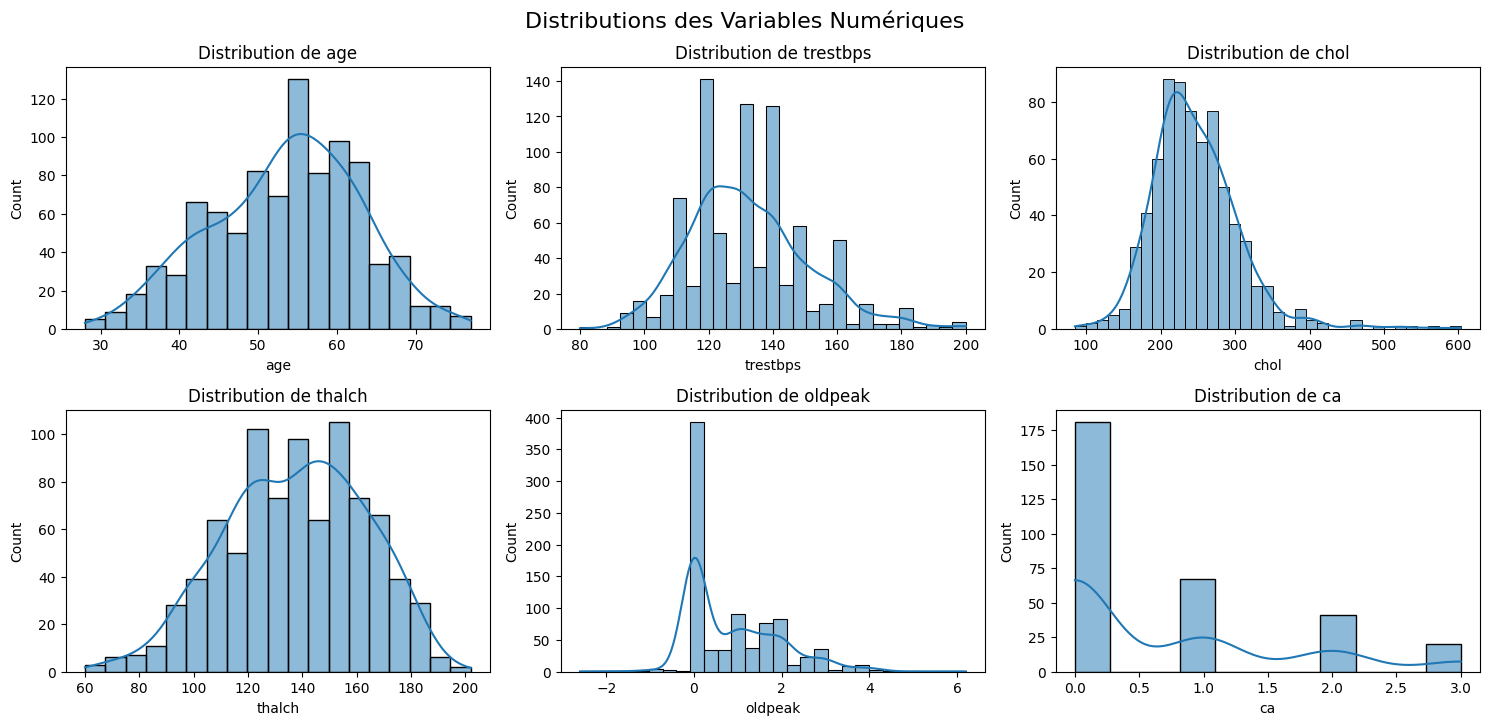

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_88829/1254557730.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_heart, x=col, palette='viridis')
/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_88829/1254557730.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_heart, x=col, palette='viridis')
/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_88829/1254557730.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_heart, x=col, palette='viridis')
/var/folders/r6/h24sb_sj1c579ck

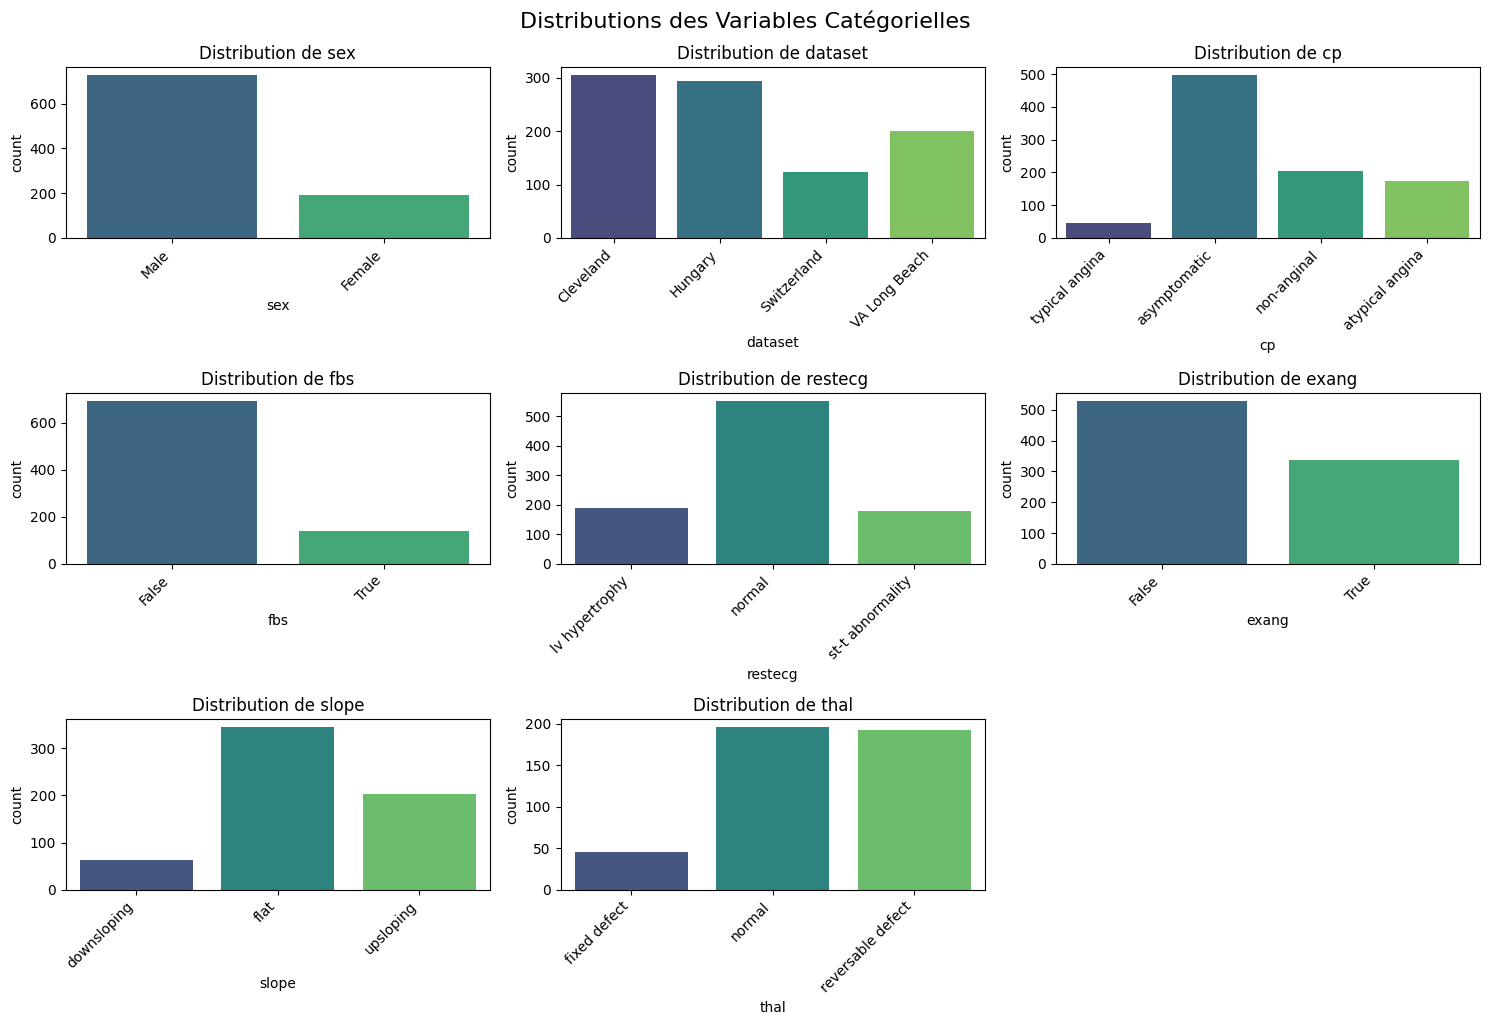

In [12]:
print("\n### 2.3 Traitement initial des valeurs aberrantes codées en 0 ###")
# Transformer les 0 aberrants en NaN pour trestbps et chol
# Une valeur de 0 pour la tension artérielle ou le cholestérol n'est pas physiologiquement possible.
# Elles sont très probablement des valeurs manquantes mal codées.
df_heart['trestbps'] = df_heart['trestbps'].replace(0, np.nan)
df_heart['chol'] = df_heart['chol'].replace(0, np.nan)

print("Valeurs 0 dans 'trestbps' et 'chol' remplacées par NaN.")
print("\nNouvelles valeurs manquantes après ce remplacement :")
missing_values_after_replacement = df_heart.isnull().sum()
print(missing_values_after_replacement[missing_values_after_replacement > 0])

print("\nProportion des valeurs manquantes après ce remplacement :")
missing_proportion_after_replacement = (df_heart.isnull().sum() / len(df_heart)) * 100
print(missing_proportion_after_replacement[missing_proportion_after_replacement > 0].round(2).astype(str) + '%')

print("\n### 2.4 Analyse des Distributions des Variables (pré-visualisation) ###")

# Séparer les colonnes par type pour la visualisation
numerical_cols = df_heart.select_dtypes(include=np.number).columns.tolist()
# Exclure 'id', 'num', et 'has_heart_disease' car ce sont des identifiants ou cibles
numerical_features = [col for col in numerical_cols if col not in ['id', 'num', 'has_heart_disease']]

categorical_cols = df_heart.select_dtypes(include='object').columns.tolist()

print("\nVariables Numériques à visualiser :", numerical_features)
print("Variables Catégorielles à visualiser :", categorical_cols)

# Visualisation des distributions numériques (histogrammes)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1) # Ajuster le layout si plus de variables
    sns.histplot(df_heart[col].dropna(), kde=True) # Utilise dropna pour ignorer les NaN
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.suptitle('Distributions des Variables Numériques', y=1.02, fontsize=16)
plt.show()

# Visualisation des distributions catégorielles (comptages)
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Ajuster le layout si plus de variables
    sns.countplot(data=df_heart, x=col, palette='viridis')
    plt.title(f'Distribution de {col}')
    plt.xticks(rotation=45, ha='right') # Rotation pour les labels longs
plt.tight_layout()
plt.suptitle('Distributions des Variables Catégorielles', y=1.02, fontsize=16)
plt.show()


# Analyse des Distributions des Variables Numériques

* Distribution Age

> Forme : asymétrique gauche (skewed left). Pic autour de 55 ans. Cela suggère que la population étudiée est majoritairement composée d'adultes d'âge moyen à avancé.

> Insight : cette asymétrie est normale pour des études sur la cardiopathie, car l'incidence augmente avec l'âge. Le modèle pourra probablement utiliser l'âge comme un bon prédicteur.


* Distribution Trestbps (Tension artérielle au repos)

> Forme : asymétrique droite (skewed right) avec un pic autour de 120 mmHg. La queue s'étend vers des valeurs plus élevées, ce qui est attendu pour l'hypertension.

> Insight : la majorité des patients ont une tension "normale" à légèrement élevée, mais il y a une présence de patients avec des tensions plus hautes. Le modèle pourra apprendre de ces variations.


* Distribution Chol (Cholestérol sérique)

> Forme : légèrement asymétrique droite, centrée autour de 220 mg/dL, avec une longue queue vers les valeurs élevées (jusqu'à 600).

> Insight : la forme est assez classique pour le cholestérol. La présence de valeurs très élevées pourrait indiquer des outliers réels ou des cas cliniques particuliers qui pourraient être pertinents pour la prédiction.


* Distribution Thalch (Fréquence cardiaque maximale atteinte)

> Forme : asymétrique gauche (skewed left), avec un plateau entre 120 et 160 bpm et un léger pic vers 140-155 bpm.

> Insight : la majorité des patients atteignent des fréquences cardiaques élevées ou moyennes pendant l'exercice, ce qui est un indicateur de la capacité cardiovasculaire.


* Distribution Oldpeak (Dépression ST)

> Forme : forte concentration à 0 (le pic à 400 counts), puis une distribution qui s'étale vers des valeurs positives. Il y a aussi des valeurs négatives (jusqu'à -2.5).

> Insight : Le pic à 0 est très important. Cela signifie qu'un grand nombre de patients n'ont pas de dépression ST, ou qu'elle est minime. La présence de valeurs positives (indiquant une ischémie - diminution de l'apport sanguin artériel à un organe -) sera très informative. Les valeurs négatives sont également des signaux.


* Distribution Ca (Nombre de vaisseaux majeurs)

> Forme : ondulatoire, mais le plus important est le très grand pic à 0.0. La majorité des patients ont 0 vaisseau majeur coloré.

> Insight : cette variable est clairement discrète et ordinales (0, 1, 2, 3) plutôt que continue. Le fait qu'elle ait un très grand nombre de valeurs manquantes (66.41%) et un pic aussi prononcé à 0.0 suggère qu'elle est souvent non enregistrée ou absente pour de nombreux patients, et que lorsqu'elle l'est, la valeur la plus fréquente est 0.

# Synthèse des Défis de Pré-traitement & Plan Raffiné

L'analyse des Distributions des Variables Numériques confirment et précisent les défis :

1. Colonnes à forte proportion de Manquants : ca (66.41%), thal (52.83%), slope (33.59%), chol (21.96%).

> Décision préliminaire : ca et thal ont trop de valeurs manquantes (> 50%). Les supprimer est la solution la plus sûre pour éviter d'introduire trop de bruit. Pour slope et chol (20-30%), c'est plus délicat ; l'imputation (médiane pour chol/slope si numérique, ou mode si catégoriel) pourrait être envisagée, mais la suppression reste une option si le modèle ne s'améliore pas.

2. Colonnes à proportion modérée de Manquants : fbs (9.78%), oldpeak (6.74%), trestbps (6.52%), thalch (5.98%), exang (5.98%).

> Décision : imputation par la médiane pour les numériques (moins sensible aux outliers) et par le mode pour les catégorielles.

3. Variables Catégorielles (Types object) : sex, dataset, cp, fbs, restecg, exang, slope, thal. Devront être encodées (One-Hot Encoding).

4. Variable id : à supprimer car c'est un simple identifiant.

5. Variable num : La colonne originale num sera supprimée après la création de has_heart_disease, car elle n'est plus nécessaire.

# Analyse des Distributions des Variables Catégorielles 

En récapitulant les observations faites

* sex (Sexe) : très majoritairement des hommes (~700) comparé aux femmes (~190). C'est un déséquilibre notable qui pourrait potentiellement introduire un biais si le modèle ne gère pas bien cette disparité.

* dataset (source du Dataset) : les sources 'Cleveland' et 'Hungary' sont les plus représentées (~300 et ~290), suivies par 'VA Long Beach' (~185) et 'Switzerland' (~110). La présence de multiples sources peut refléter des méthodes de collecte ou des populations légèrement différentes.

* cp (Type de Douleur Thoracique) : la catégorie 'asymptomatic' est très dominante (>500), suivie par 'non-anginal' (>200) et 'atypical angina' (~185). 'typical angina' est très minoritaire (~30). Le déséquilibre ici est très fort, surtout pour 'typical angina'.

* fbs (Glycémie à jeun > 120 mg/dl) : la valeur 'False' (glycémie normale) est largement majoritaire (>650) par rapport à 'True' (>150). C'est attendu, car l'hyperglycémie à jeun est un indicateur de risque.

* restecg (Résultats ECG au repos) : la catégorie 'normal' est la plus fréquente (>510), suivie de près par 'lv hypertrophy' (~190) et 'st-t abnormality' (~190). Plutôt bien équilibré entre les deux dernières, avec une nette majorité pour "normal".

* exang (Angine induite par l'exercice) : la valeur 'False' (pas d'angine à l'exercice) est plus fréquente (>500) que 'True' (>300). C'est un indicateur clé.

* slope (Pente du segment ST du pic d'exercice) : la catégorie 'flat' est de loin la plus fréquente (>310), suivie de 'upsloping' (~190) et 'downsloping' (~50). Comme noté précédemment, cette colonne a aussi un taux très élevé de valeurs manquantes (33.59%).

* thal (Thalassémie) : Les catégories 'normal' et 'reversable defect' sont les plus présentes (~190 chacune), avec 'fixed defect' (~45) étant minoritaire. Cette colonne a un taux très élevé de valeurs manquantes (52.83%).

# Étape 3 : Pré-traitement des Données

# Synthèse Finale du Plan de Pré-traitement

Nous avons maintenant toutes les informations nécessaires pour établir un plan de pré-traitement clair et robuste.

1. Suppression des colonnes non pertinentes ou trop manquantes

> id : à supprimer car c'est un identifiant unique sans valeur prédictive.

> num : à supprimer car nous avons créé notre variable cible binaire has_heart_disease.

> ca : à supprimer (66.41% de valeurs manquantes). Tenter de l'imputer introduirait trop de bruit ou de faux motifs.

> thal : à supprimer (52.83% de valeurs manquantes). Même raison que ca.

> slope : à supprimer (33.59% de valeurs manquantes). Bien que moins que ca et thal, un tiers des données manquantes pour une variable catégorielle est élevé et pourrait affecter la performance. Pour un premier modèle, la prudence est de le retirer. Si les performances sont insuffisantes, nous pourrions reconsidérer une imputation plus avancée.


2. Gestion des Valeurs Manquantes Restantes (par Imputation)

> Numériques : trestbps (6.52%), chol (21.96%), thalch (5.98%), oldpeak (6.74%).

>> Stratégie : imputation par la médiane pour ces colonnes. La médiane est moins sensible aux outliers que la moyenne et préserve mieux la forme de la distribution.


> Catégorielles : fbs (9.78%), restecg (0.22%), exang (5.98%).

>> Stratégie : imputation par le mode (la catégorie la plus fréquente) pour ces colonnes. C'est simple et efficace pour des taux de manquants modérés.


3. Encodage des Variables Catégorielles

> Colonnes à encoder : sex, dataset, cp, fbs, restecg, exang.

>> Stratégie : utiliser le One-Hot Encoding. Cette méthode crée une nouvelle colonne binaire pour chaque catégorie unique, évitant ainsi d'introduire une relation d'ordre arbitraire que le modèle pourrait mal interpréter.


4. Scaling des Caractéristiques Numériques

> Colonnes à scaler : age, trestbps, chol, thalch, oldpeak.

>>Stratégie : utiliser le StandardScaler. Il transforme les données pour qu'elles aient une moyenne de 0 et un écart-type de 1. C'est crucial pour la régression logistique et d'autres algorithmes basés sur la distance ou les gradients, car cela assure que chaque caractéristique contribue de manière équivalente, sans qu'une variable avec de grandes valeurs n'écrase l'influence d'une variable avec de petites valeurs.


# Prochaine Étape : Implémentation du Pré-traitement

Ce que ce script fait :

1. Suppression de colonnes : retire id, num, ca, thal, slope du DataFrame.

2. Identification des features : sépare les colonnes restantes en listes numériques et catégorielles.

3. Création de Pipelines

> Pour les numériques : impute les NaN avec la médiane, puis applique un StandardScaler.

> Pour les catégorielles : impute les NaN avec le mode, puis applique le One-Hot Encoding.

4. ColumnTransformer : combine ces pipelines pour les appliquer simultanément aux bonnes colonnes. C'est une approche très robuste et propre de scikit-learn.

5. Application : fit_transform le préprocesseur sur nos features (X) et sépare la cible (y).

6. Vérification : affiche les dimensions du dataset transformé et les premières lignes d'un DataFrame temporaire créé pour visualiser le résultat du pré-traitement (notamment l'effet du One-Hot Encoding).

In [18]:
# Rechargement du DataFrame si nécessaire (pour autonomie du script)
try:
    df_heart
except NameError:
    print("Le DataFrame 'df_heart' n'est pas défini. Rechargement du fichier CSV...")
    df_heart = pd.read_csv('heart_disease_uci.csv')
    # Les 0 aberrants sont remplacés par NaN dès le rechargement si le df n'est pas déjà là
    df_heart['trestbps'] = df_heart['trestbps'].replace(0, np.nan)
    df_heart['chol'] = df_heart['chol'].replace(0, np.nan)
    print("DataFrame 'df_heart' rechargé et préparé.")


print("\n--- Étape 3 : Pré-traitement des Données (Correction Appliquée) ---")

# --- CORRECTION MAJEURE ICI : Création de la cible 'y' AVANT toute modification des features 'X' ---
# Création de la variable cible binaire 'y'
# 0 = pas de maladie cardiaque (num = 0)
# 1 = présence de maladie cardiaque (num > 0)
y = df_heart['num'].apply(lambda x: 1 if x > 0 else 0)
print(f"Variable cible 'y' créée. Dimensions : {y.shape}")

# 3.1 Suppression des colonnes non pertinentes ou avec trop de manquants
# Maintenant, nous supprimons 'num' et 'id' du DataFrame qui deviendra nos features (X).
# 'ca', 'thal', 'slope' sont également supprimées comme décidé.
columns_to_drop_for_features = ['id', 'num', 'ca', 'thal', 'slope']
X = df_heart.drop(columns=columns_to_drop_for_features)

print(f"Colonnes supprimées du DataFrame des features (X) : {columns_to_drop_for_features}")
print(f"Nouvelles dimensions du DataFrame de features (X) : {X.shape}")


# 3.2 Identification des colonnes numériques et catégorielles restantes dans X
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"\nVariables numériques à traiter : {numerical_features}")
print(f"Variables catégorielles à traiter : {categorical_features}")

# 3.3 Création des Pipelines de Pré-traitement (Imputation et Encodage/Scaling)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Imputation par la médiane
    ('scaler', StandardScaler())                    # Standardisation
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputation par le mode
    ('onehot', OneHotEncoder(handle_unknown='ignore'))     # One-Hot Encoding
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\nTransformateurs (Imputation, Scaling, Encodage) créés.")

# 3.4 Application du pré-traitement
print("Application du pré-traitement au DataFrame de features (X)...")
X_processed = preprocessor.fit_transform(X) # Appliquer sur X, qui ne contient plus la cible

# Obtenir les noms des colonnes après One-Hot Encoding
# C'est important pour pouvoir créer un DataFrame des features transformées avec les bons noms
encoded_feature_names = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed, columns=encoded_feature_names)


print("\nPré-traitement terminé. Dimensions des features transformées :", X_processed.shape)
print("\nPremières lignes du DataFrame de features transformées (X_processed_df) :")
print(X_processed_df.head())
print("\nTypes de données des features transformées (devraient être numériques, float64) :")
print(X_processed_df.dtypes.value_counts())


--- Étape 3 : Pré-traitement des Données (Correction Appliquée) ---
Variable cible 'y' créée. Dimensions : (920,)
Colonnes supprimées du DataFrame des features (X) : ['id', 'num', 'ca', 'thal', 'slope']
Nouvelles dimensions du DataFrame de features (X) : (920, 11)

Variables numériques à traiter : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Variables catégorielles à traiter : ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang']

Transformateurs (Imputation, Scaling, Encodage) créés.
Application du pré-traitement au DataFrame de features (X)...

Pré-traitement terminé. Dimensions des features transformées : (920, 22)

Premières lignes du DataFrame de features transformées (X_processed_df) :
   num__age  num__trestbps  num__chol  num__thalch  num__oldpeak  \
0  1.007386       0.705176   0.303643     0.489727      1.368109   
1  1.432034       1.518569   0.789967    -1.181478      0.611589   
2  1.432034      -0.650479   0.266939    -0.345875      1.651804   
3 -1.752828      -0.1082

# Récapitulatif du Pré-traitement Terminé

1. Cible séparée : la variable cible y (has_heart_disease) est maintenant correctement extraite et isolée du reste des données. Ses dimensions (920,) confirment qu'elle contient bien une valeur pour chaque patient.


2. Colonnes nettoyées : nous avons supprimé les colonnes id, num, ca, thal, et slope, comme décidé, réduisant notre DataFrame de features X à 11 colonnes initialement. C'est une bonne optimisation pour se concentrer sur les données les plus fiables.


3. Features Identifiées

* Numériques (age, trestbps, chol, thalch, oldpeak) : ces 5 variables sont prêtes à être imputées par la médiane et standardisées.

* Catégorielles (sex, dataset, cp, fbs, restecg, exang) : ces 6 variables sont prêtes à être imputées par le mode et encodées en One-Hot.


4. Transformation appliquée : le ColumnTransformer a orchestré l'imputation des valeurs manquantes, la standardisation des numériques et le One-Hot Encoding des catégorielles.

* Le X_processed.shape de (920, 22) montre que nos 11 colonnes initiales ont été transformées en 22 features. Cette augmentation est due au One-Hot Encoding des variables catégorielles, qui crée plusieurs colonnes binaires pour chaque catégorie.

* Les premières lignes de X_processed_df montrent clairement les effets : des valeurs numériques standardisées (autour de 0) et des colonnes cat__ avec des 0.0 ou 1.0 pour représenter les catégories.

* Le float64 22 pour les types de données confirme que toutes nos features sont maintenant numériques et prêtes pour un modèle de machine learning.

Nous avons maintenant un ensemble de données (X_processed et y) propre, transformé et parfaitement structuré pour l'entraînement d'un modèle de machine learning.

# Étape 4 : Modélisation

In [ ]:

try:
    X_processed
    y
except NameError:
    print("X_processed ou y n'existent pas. Veuillez exécuter les étapes précédentes de chargement et de pré-traitement.")
    # Pour un script autonome, vous pourriez vouloir inclure tout le code précédent ici
    # ou charger des versions enregistrées de X_processed et y si vous les avez sauvegardées.
    exit() # Arrête l'exécution si les variables ne sont pas définies


print("\n--- Étape 4 : Modélisation (Régression Logistique) ---")

# 4.1 Division du Dataset en ensembles d'entraînement et de test
# Nous allons utiliser 80% des données pour l'entraînement et 20% pour le test.
# 'random_state' assure la reproductibilité de la division.
# 'stratify=y' assure que la proportion des classes (0 et 1) est la même dans les ensembles d'entraînement et de test,
# ce qui est crucial pour un problème de classification.
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDimensions de l'ensemble d'entraînement (X_train) : {X_train.shape}")
print(f"Dimensions de l'ensemble de test (X_test) : {X_test.shape}")
print(f"Dimensions de la cible d'entraînement (y_train) : {y_train.shape}")
print(f"Dimensions de la cible de test (y_test) : {y_test.shape}")

# Vérifier la répartition des classes dans les ensembles d'entraînement et de test
print("\nRépartition des classes dans y_train :")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print("\nRépartition des classes dans y_test :")
print(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


# 4.2 Entraînement du modèle de Régression Logistique
# Nous utilisons un paramètre 'max_iter' pour assurer la convergence de l'algorithme,
# et 'solver' pour la robustesse (par exemple 'liblinear' ou 'lbfgs' pour les petits datasets).
# 'class_weight="balanced"' est une option pour gérer le déséquilibre des classes si nécessaire,
# mais ici, le déséquilibre (45% vs 55%) n'est pas extrême, donc nous ne l'utiliserons pas par défaut.
# Nous utiliserons l'algorithme 'lbfgs' car il est un bon choix par défaut pour la plupart des problèmes.
model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')

print("\nEntraînement du modèle de Régression Logistique sur l'ensemble d'entraînement...")
model.fit(X_train, y_train)
print("Modèle de Régression Logistique entraîné avec succès !")

# Une petite vérification de la performance sur l'entraînement (juste pour info, pas l'évaluation finale)
train_accuracy = model.score(X_train, y_train)
print(f"Précision du modèle sur l'ensemble d'entraînement : {train_accuracy:.4f}")


--- Étape 4 : Modélisation (Régression Logistique) ---

Dimensions de l'ensemble d'entraînement (X_train) : (736, 22)
Dimensions de l'ensemble de test (X_test) : (184, 22)
Dimensions de la cible d'entraînement (y_train) : (736,)
Dimensions de la cible de test (y_test) : (184,)

Répartition des classes dans y_train :
num
1    55.3%
0    44.7%
Name: proportion, dtype: object

Répartition des classes dans y_test :
num
1    55.43%
0    44.57%
Name: proportion, dtype: object

Entraînement du modèle de Régression Logistique sur l'ensemble d'entraînement...
Modèle de Régression Logistique entraîné avec succès !
Précision du modèle sur l'ensemble d'entraînement : 0.8207


# Observations

1. Importations : ajoute train_test_split et LogisticRegression de scikit-learn.


2. Vérification des données : un bloc try-except vérifie si X_processed et y sont bien présents, nous rappelant d'exécuter les étapes précédentes si ce n'est pas le cas.


3. Division des données (train_test_split)

* Divise X_processed et y en 80% pour l'entraînement (X_train, y_train) et 20% pour le test (X_test, y_test).

* random_state=42 : rend la division reproductible.

* stratify=y : maintient la même proportion de classes (malades/non-malades) dans les ensembles d'entraînement et de test que dans le dataset original. C'est crucial pour des résultats d'évaluation fiables, surtout si les classes sont déséquilibrées.


4. Vérification des dimensions et proportions : affiche les dimensions des nouveaux ensembles et la répartition des classes.


5. Entraînement du modèle (LogisticRegression)

* Crée une instance de LogisticRegression.

* random_state=42 : pour la reproductibilité de l'entraînement.

* max_iter=1000 : augmente le nombre maximum d'itérations pour que le solveur ait suffisamment de temps pour converger (éviter les avertissements de convergence).

* solver='lbfgs' : un algorithme d'optimisation robuste et polyvalent.

* model.fit(X_train, y_train) : entraîne le modèle sur les données d'entraînement.


6. Précision d'entraînement : calcule et affiche la précision sur l'ensemble d'entraînement comme un premier indicateur rapide.

# Illustration de l'Entrainement

Ce graphique à barres montre le nombre de patients avec et sans maladie cardiaque (Has_Heart_Disease) pour l'ensemble total des données, l'ensemble d'entraînement, et l'ensemble de test. Grâce à stratify=y lors de la division, nous observons que les proportions de barres bleues (pas de maladie) et oranges (maladie) sont visuellement similaires pour les trois ensembles, confirmant que nos jeux de données sont représentatifs de la distribution originale.

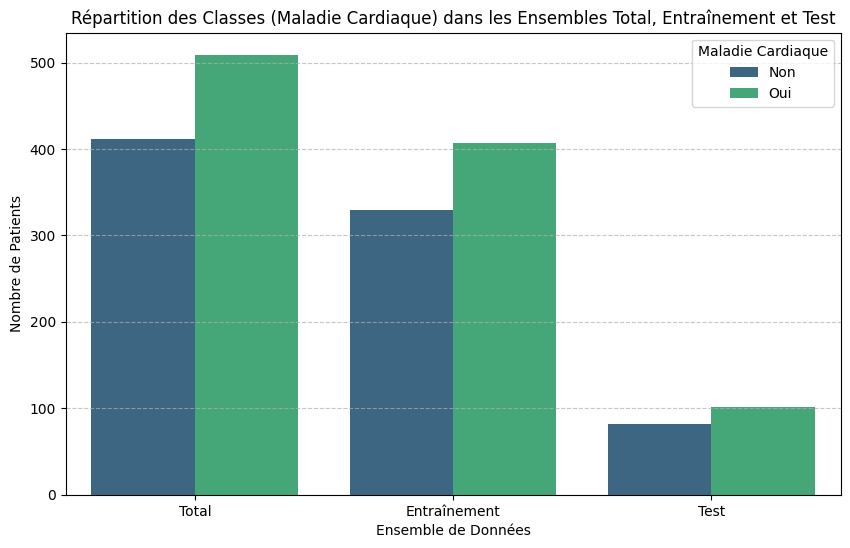

In [21]:
# Création d'un DataFrame pour faciliter la visualisation des proportions
df_proportions = pd.DataFrame({
    'Ensemble': ['Total'] * len(y) + ['Entraînement'] * len(y_train) + ['Test'] * len(y_test),
    'Has_Heart_Disease': pd.concat([y, y_train, y_test])
})

plt.figure(figsize=(10, 6))
sns.countplot(data=df_proportions, x='Ensemble', hue='Has_Heart_Disease', palette='viridis')
plt.title('Répartition des Classes (Maladie Cardiaque) dans les Ensembles Total, Entraînement et Test')
plt.xlabel('Ensemble de Données')
plt.ylabel('Nombre de Patients')
plt.xticks(ha='center')
plt.legend(title='Maladie Cardiaque', labels=['Non', 'Oui'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Étape 5 : Évaluation du Modèle

Ce que ce script fait :

1. Prédictions : utilise le modèle entraîné pour prédire les labels (y_pred) et les probabilités (y_pred_proba) sur l'ensemble de test.

2. Calcul des Métriques : calcule l'accuracy, la precision, le recall et le F1-score.

3. Rapport de Classification : affiche un résumé complet des métriques par classe.

4. Matrice de Confusion : crée un heatmap visuel de la matrice de confusion pour comprendre les vrais positifs, vrais négatifs, faux positifs et faux négatifs.

5. Courbe ROC et AUC : un ajout important pour les problèmes de classification. L'AUC mesure la capacité du modèle à distinguer les classes. Plus l'AUC est proche de 1, meilleur est le modèle.


--- Étape 5 : Évaluation du Modèle ---

### 5.2 Calcul des Métriques de Performance ###
Accuracy (Précision globale) : 0.8370
Precision (Prédictions positives correctes) : 0.8396
Recall (Taux de détection des vrais positifs) : 0.8725
F1-Score (Équilibre Précision/Rappel) : 0.8558

### 5.3 Rapport de Classification ###
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


### 5.4 Matrice de Confusion ###


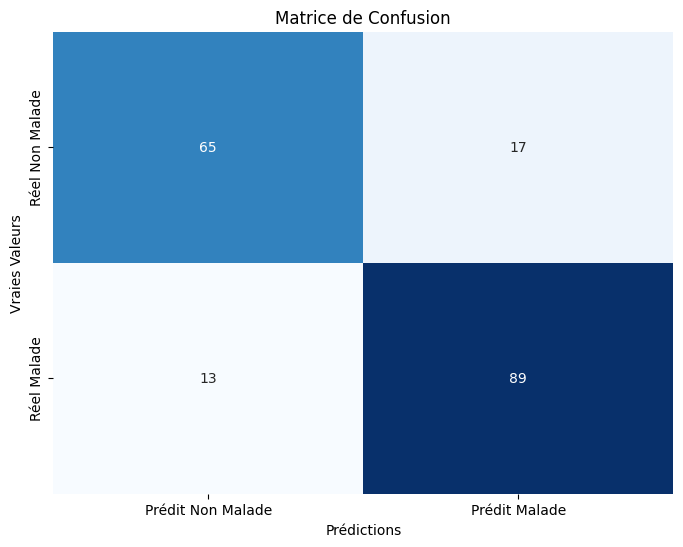


### 5.5 Courbe ROC et AUC ###


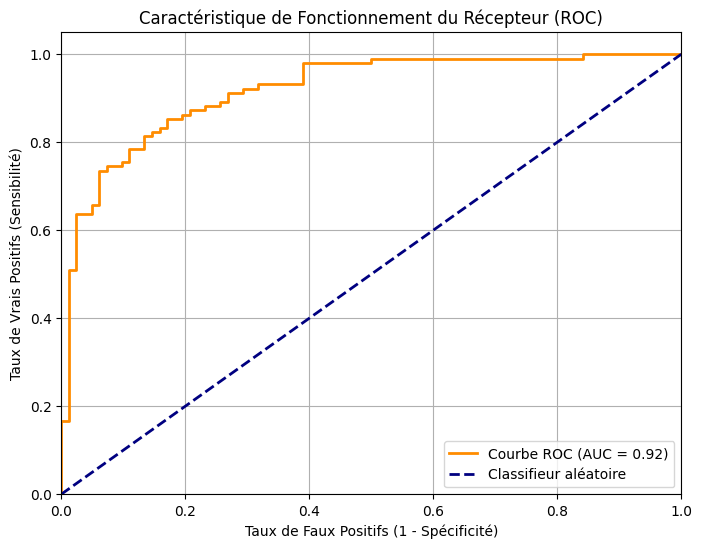


Area Under the Curve (AUC) : 0.9195


In [24]:
print("\n--- Étape 5 : Évaluation du Modèle ---")

# 5.1 Prédictions sur l'ensemble de test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probabilités pour la classe positive (maladie)

# 5.2 Calcul des Métriques de Performance
print("\n### 5.2 Calcul des Métriques de Performance ###")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy (Précision globale) : {accuracy:.4f}")
print(f"Precision (Prédictions positives correctes) : {precision:.4f}")
print(f"Recall (Taux de détection des vrais positifs) : {recall:.4f}")
print(f"F1-Score (Équilibre Précision/Rappel) : {f1:.4f}")

# 5.3 Affichage du Rapport de Classification
print("\n### 5.3 Rapport de Classification ###")
print(classification_report(y_test, y_pred))

# 5.4 Visualisation de la Matrice de Confusion
print("\n### 5.4 Matrice de Confusion ###")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prédit Non Malade', 'Prédit Malade'],
            yticklabels=['Réel Non Malade', 'Réel Malade'])
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion')
plt.show()

# (Optionnel) Courbe ROC et AUC (Ajouté pour une évaluation plus complète)
from sklearn.metrics import roc_curve, roc_auc_score

print("\n### 5.5 Courbe ROC et AUC ###")
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
plt.title('Caractéristique de Fonctionnement du Récepteur (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nArea Under the Curve (AUC) : {auc:.4f}")

# Analyse des Résultats de l'Évaluation du Modèle

Les résultats de l'évaluation sur l'ensemble de test sont très prometteurs :

* Accuracy (Précision globale) : 0.8370 (83.7%)

> Le modèle prédit correctement le statut de cardiopathie pour environ 83.7% des patients. C'est un bon score global.


* Precision (Prédictions positives correctes) : 0.8396 (83.96%)

> Quand le modèle prédit qu'un patient a une maladie cardiaque, il a raison dans près de 84% des cas. Cela signifie un faible taux de faux positifs (diagnostics erronés de maladie alors qu'il n'y en a pas).


* Recall (Taux de détection des vrais positifs) : 0.8725 (87.25%)

> Le modèle parvient à identifier 87.25% des patients qui ont réellement une maladie cardiaque. C'est une excellente nouvelle, car cela signifie un faible taux de faux négatifs (patients malades non détectés), ce qui est crucial en médecine pour éviter de passer à côté de cas réels.


* F1-Score (Équilibre Précision/Rappel) : 0.8558 (85.58%)

> Le F1-Score est une moyenne harmonieuse de la précision et du rappel. Un score élevé (ici 85.58%) indique que le modèle est équilibré et performant sur les deux fronts, ce qui est généralement désirable.


* Rapport de Classification

> Classe 0 (Pas de maladie) : Précision de 0.83, Rappel de 0.79, F1-Score de 0.81.

> Classe 1 (Maladie présente) : Précision de 0.84, Rappel de 0.87, F1-Score de 0.86.

> Le modèle est légèrement meilleur pour détecter la classe positive (maladie), ce qui est souvent préférable dans un contexte médical où manquer une maladie peut avoir de graves conséquences.


* Matrice de Confusion

> Vrais Négatifs (TN) : 65 (Le modèle a correctement prédit 65 patients sans maladie cardiaque)

> Faux Positifs (FP) : 17 (Le modèle a prédit à tort 17 patients comme malades)

> Faux Négatifs (FN) : 13 (Le modèle a manqué 13 patients réellement malades)

> Vrais Positifs (TP) : 89 (Le modèle a correctement identifié 89 patients malades)

> Ces chiffres confirment les métriques : le nombre de faux négatifs (13) est relativement faible par rapport aux vrais positifs (89). Le nombre de faux positifs (17) est aussi contrôlé.


* Area Under the Curve (AUC) : 0.9195 (91.95%)

> Un score AUC de près de 0.92 est excellent. Cela indique que le modèle a une très forte capacité à distinguer les patients atteints de cardiopathie de ceux qui ne le sont pas. Plus l'AUC est proche de 1, mieux le modèle sépare les classes.


* Courbe ROC

La courbe monte rapidement vers le coin supérieur gauche, ce qui est le signe d'un bon classifieur. Elle montre que nous pouvons obtenir un taux de vrais positifs élevé (sensibilité) sans un coût excessif en faux positifs. Les "paliers" sont normaux pour des datasets avec un nombre fini d'observations.

# Conclusion primaire

Le modèle de Régression Logistique entraîné démontre une performance solide et fiable pour la prédiction de la cardiopathie sur ce dataset. Son Recall élevé et son excellent AUC sont particulièrement encourageants dans un contexte médical, où il est primordial de minimiser le risque de ne pas diagnostiquer une maladie présente.

# Ajout du Modèle Random Forest et Comparaison Binaire


--- Ajout du Modèle Random Forest et Comparaison Binaire ---

### Performance de la Régression Logistique (rappel) ###
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        82
           1       0.84      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

AUC (Logistic Regression) : 0.9195

### 5.2 Entraînement et Évaluation du Modèle Random Forest ###
Entraînement du modèle Random Forest sur l'ensemble d'entraînement...
Modèle Random Forest entraîné avec succès !

Performance du Random Forest sur l'ensemble de test :
              precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg 

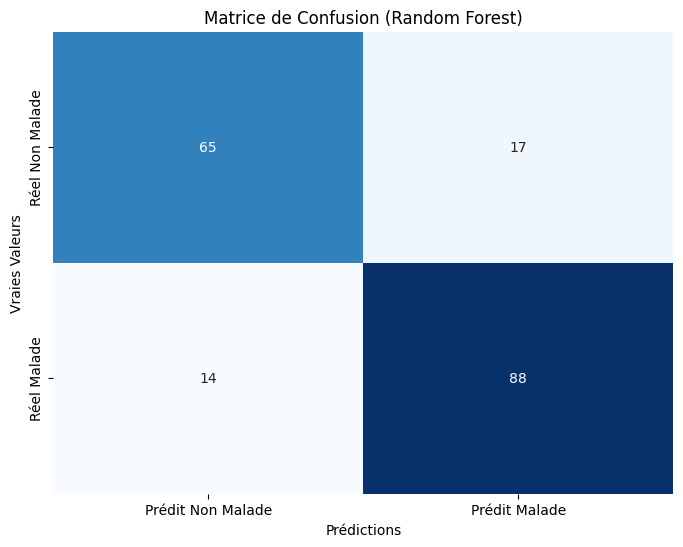


### 5.3 Comparaison des Modèles Binaires (Régression Logistique vs Random Forest) ###
AUC Régression Logistique : 0.9195
AUC Random Forest       : 0.9254


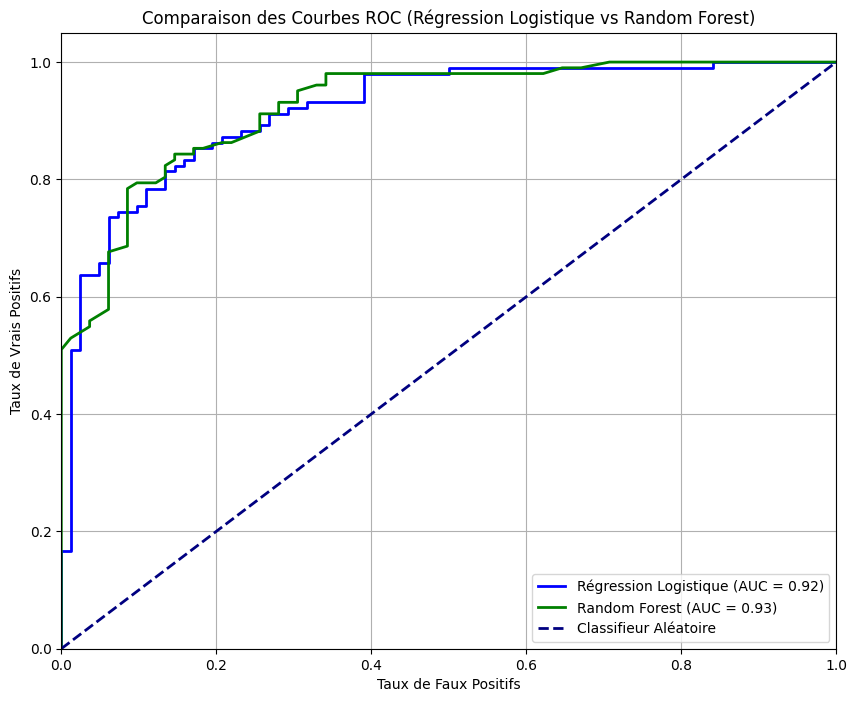


Tableau comparatif des métriques :
           Logistic Regression  Random Forest
Metric                                       
Accuracy                0.8370         0.8315
Precision               0.8396         0.8381
Recall                  0.8725         0.8627
F1-Score                0.8558         0.8502


In [32]:
print("\n--- Ajout du Modèle Random Forest et Comparaison Binaire ---")

# --- 5.1 Re-calcul des prédictions pour la Régression Logistique ---
y_pred_lr = model.predict(X_test)
y_pred_proba_lr = model.predict_proba(X_test)[:, 1] # Probabilités pour la classe positive

print("\n### Performance de la Régression Logistique (rappel) ###")
print(classification_report(y_test, y_pred_lr))
print(f"AUC (Logistic Regression) : {roc_auc_score(y_test, y_pred_proba_lr):.4f}")


# --- 5.2 Entraînement et Évaluation du modèle Random Forest ---
print("\n### 5.2 Entraînement et Évaluation du Modèle Random Forest ###")

# Création et entraînement du modèle Random Forest
# Nous utilisons un random_state pour la reproductibilité.
# n_estimators: nombre d'arbres dans la forêt.
# class_weight: peut aider si le déséquilibre est plus prononcé, mais ici, 'balanced' est un bon défaut.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("Entraînement du modèle Random Forest sur l'ensemble d'entraînement...")
rf_model.fit(X_train, y_train)
print("Modèle Random Forest entraîné avec succès !")

# Prédictions sur l'ensemble de test pour Random Forest
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Métriques de performance pour Random Forest
print("\nPerformance du Random Forest sur l'ensemble de test :")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion pour Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prédit Non Malade', 'Prédit Malade'],
            yticklabels=['Réel Non Malade', 'Réel Malade'])
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion (Random Forest)')
plt.show()

# --- 5.3 Comparaison des Modèles Binaires (RL vs RF) ---
print("\n### 5.3 Comparaison des Modèles Binaires (Régression Logistique vs Random Forest) ###")

# Collecte des AUC pour la comparaison
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"AUC Régression Logistique : {auc_lr:.4f}")
print(f"AUC Random Forest       : {auc_rf:.4f}")

# Tracé des courbes ROC des deux modèles sur le même graphique
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Régression Logistique (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Comparaison des Courbes ROC (Régression Logistique vs Random Forest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Comparaison des métriques clés
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
}
df_comparison = pd.DataFrame(comparison_data).set_index('Metric')
print("\nTableau comparatif des métriques :")
print(df_comparison.round(4))

# Analyse et Comparaison des Modèles Binaires : Régression Logistique vs. Random Forest


Nous avons maintenant entraîné et évalué deux modèles différents pour notre classification binaire, et les résultats sont fascinants.

1. Performances du Random Forest

* Rapport de Classification (Random Forest) :

> Accuracy : 0.83 (83%)

> Precision (Classe 1 - Maladie) : 0.84 (84%)

> ecall (Classe 1 - Maladie) : 0.86 (86%)

> F1-Score (Classe 1 - Maladie) : 0.85 (85%)

> Le Random Forest montre également de très bonnes performances, avec des métriques très proches de celles de la régression logistique. Il gère bien la détection des deux classes.


* Matrice de Confusion (Random Forest)

> Vrais Négatifs (TN) : 65 (Le modèle RF a correctement prédit 65 patients sans maladie cardiaque).

> Faux Positifs (FP) : 17 (Le modèle RF a prédit à tort 17 patients comme malades).

> Faux Négatifs (FN) : 14 (Le modèle RF a manqué 14 patients réellement malades).

> Vrais Positifs (TP) : 88 (Le modèle RF a correctement identifié 88 patients malades).


= Comparaison avec la Régression Logistique (RL) =

RL : TN=65, FP=17, FN=13, TP=89

RF : TN=65, FP=17, FN=14, TP=88


= Impact de comparaison =

* Vrais Négatifs (TN) et Faux Positifs (FP) : les deux modèles ont exactement les mêmes nombres (65 TN, 17 FP). Cela signifie qu'ils sont identiques en termes de spécificité et de précision des prédictions négatives. Quand ils disent qu'il n'y a pas de maladie, ou qu'ils se trompent en diagnostiquant une maladie, ils le font de la même manière.

* Vrais Positifs (TP) et Faux Négatifs (FN) : c'est ici que la très légère différence apparaît, comme les métriques nous l'indiquaient :

> La Régression Logistique (89 TP, 13 FN) identifie un vrai positif de plus et fait un faux négatif de moins que le Random Forest (88 TP, 14 FN).

Cette observation est cruciale dans un contexte médical. Un Faux Négatif (FN) est généralement plus coûteux qu'un Faux Positif (FP). Manquer une maladie (FN) peut avoir des conséquences graves pour le patient. Diagnostiquer à tort une maladie (FP) entraîne des tests et du stress inutiles, mais est moins risqué pour la santé du patient.

Puisque la Régression Logistique a un nombre de Faux Négatifs légèrement inférieur (13 contre 14) et un nombre de Vrais Positifs légèrement supérieur (89 contre 88), elle conserve son léger avantage en termes de rappel (Recall) et, par extension, sa pertinence dans un scénario clinique où la détection maximale des cas réels est priorisée.


2. Comparaison des Modèles Binaires (RL vs. RF) :

Metric         Logistic Regression         Random Forest

Accuracy               0.8370                   0.8315

Precision              0.8396                   0.8381

Recall                 0.8725                   0.8627

F1-Score               0.8558                   0.8502

AUC                    0.9195                   0.9254


* Accuracy : la Régression Logistique (0.8370) est légèrement, mais très légèrement, supérieure en précision globale.

* Precision : la Régression Logistique (0.8396) a une précision marginalement supérieure pour la classe positive.

* Recall : la Régression Logistique (0.8725) a un rappel légèrement supérieur, ce qui signifie qu'elle détecte un peu mieux les vrais cas positifs (patients malades). C'est souvent une métrique très importante en médecine.

* F1-Score : la Régression Logistique (0.8558) a un F1-score très légèrement supérieur, indiquant un meilleur équilibre global entre précision et rappel.

* AUC : le Random Forest (0.9254) a un AUC légèrement plus élevé que la Régression Logistique (0.9195). Cela suggère que le Random Forest a une capacité marginalement supérieure à discriminer les classes sur l'ensemble des seuils de classification.


= Interprétation du graphique de comparaison des Courbes ROC =

* Courbes qui se chevauchent et se croisent : cela indique que les deux modèles, Régression Logistique (bleue) et Random Forest (verte), ont des performances très similaires sur l'ensemble des seuils de classification. Il n'y a pas un modèle qui domine clairement l'autre sur toute la plage de sensibilité/spécificité.


* Comportement au démarrage (0-0.2 Taux de Faux Positifs - FP)

> La courbe bleue (RL) démarre légèrement en dessous de 0.2 de Taux de Vrais Positifs (VP).

> La verte (RF) démarre à peu près au même endroit mais atteint la hauteur de la bleue plus rapidement (à 0.5+ VP).

> Interprétation : dans la région où nous cherchons à maintenir un taux de faux positifs très bas (c'est-à-dire une haute spécificité), le Random Forest pourrait avoir un léger avantage en atteignant un taux de vrais positifs légèrement plus élevé plus tôt. Cela signifie qu'à très faible tolérance aux erreurs de type I (diagnostiquer à tort une maladie), le RF pourrait être un peu plus "sensible" que la RL.


* Comportement autour de 0.2-0.3 Taux de FP

> Les courbes s'entrecroisent à 0.2 FP, avec le vert (RF) au-dessus, puis le bleu (RL) repasse au-dessus à 0.3 FP et environ 0.85 VP.

> Interprétation : cette alternance suggère que selon le point de fonctionnement spécifique (le compromis souhaité entre FP et VP), un modèle pourrait être légèrement préférable à l'autre. La RL est légèrement plus performante lorsque l'on accepte un peu plus de faux positifs pour gagner un peu plus en vrais positifs (autour de 0.85 VP).


* Comportement vers la fin (proche de 0.4 FP, les courbes se lissent et approchent 1.0 VP)

> Les deux courbes se rejoignent et montent très haut en VP pour un taux de FP modéré.

> Interprétation : cela confirme l'excellente capacité de discrimination des deux modèles. Ils sont tous deux capables d'atteindre un très haut taux de détection de la maladie, même si cela implique d'accepter un taux de faux positifs d'environ 0.4.


# Conclusion de l'Approche Binaire

La différence de performance entre la Régression Logistique et le Random Forest est marginale pour la classification binaire.

* Le Random Forest semble avoir un très léger avantage lorsque l'on est extrêmement strict sur le taux de faux positifs (début de la courbe), suggérant qu'il est peut-être un peu plus performant pour identifier correctement les cas positifs avec une très haute confiance.

* La Régression Logistique maintient une performance très robuste et légèrement supérieure en Recall et F1-Score sur l'ensemble de test (comme vu dans le tableau), ce qui reste un atout majeur pour détecter les patients malades sans trop de compromis.


Les deux modèles sont d'excellents candidats. Le choix final pour un déploiement binaire pourrait donc se baser non seulement sur cette très légère différence de performance, mais aussi sur des considérations pratiques :

* Interprétabilité : la Régression Logistique offre des coefficients directement interprétables, ce qui peut être un avantage clinique.

* Robustesse : le Random Forest est intrinsèquement plus robuste aux valeurs aberrantes et peut capturer des relations non-linéaires plus complexes.


Puisque les performances sont si proches, et que la régression logistique offre une transparence accrue (ce qui est souvent valorisé en médecine), elle reste un excellent choix de "modèle de référence" pour cette tâche binaire. Cependant, le Random Forest montre qu'il est tout aussi capable et pourrait être préféré si la non-linéarité et la robustesse sont des priorités absolues.

Le choix pourrait se jouer sur des facteurs comme l'interprétabilité (avantage RL) ou la robustesse face à des données un peu plus bruitées à l'avenir (léger avantage RF).

# Ajout de Modèles

Ce que ce script fait :

1. Bloc de re-chargement/pré-traitement : un bloc try-except plus complet pour s'assurer que toutes les variables (X_processed, y, X_train, X_test, y_train, y_test) sont bien définies si le script est exécuté de manière isolée.

2. Matrice de Corrélation : calcule et affiche une heatmap de corrélation pour les features numériques transformées et la variable cible has_heart_disease.

3. Entraînement et évaluation de KNN et SVM : des instances de KNeighborsClassifier et SVC sont créées, entraînées sur X_train/y_train et évaluées sur X_test.

> Pour SVM, probability=True est essentiel pour pouvoir utiliser predict_proba et ainsi tracer la courbe ROC et calculer l'AUC. Cela peut rendre l'entraînement plus long.

4. Comparaison Globale

> Un dictionnaire models est créé pour stocker tous les modèles et leurs prédictions.

> Un tableau comparatif est généré, regroupant l'Accuracy, la Precision, le Recall, le F1-Score et l'AUC pour chaque modèle.

> Un graphique des courbes ROC superposées est généré pour une comparaison visuelle directe.


--- Étape 2.5 (Nouveau) : Matrice de Corrélation (pour les features numériques transformées) ---


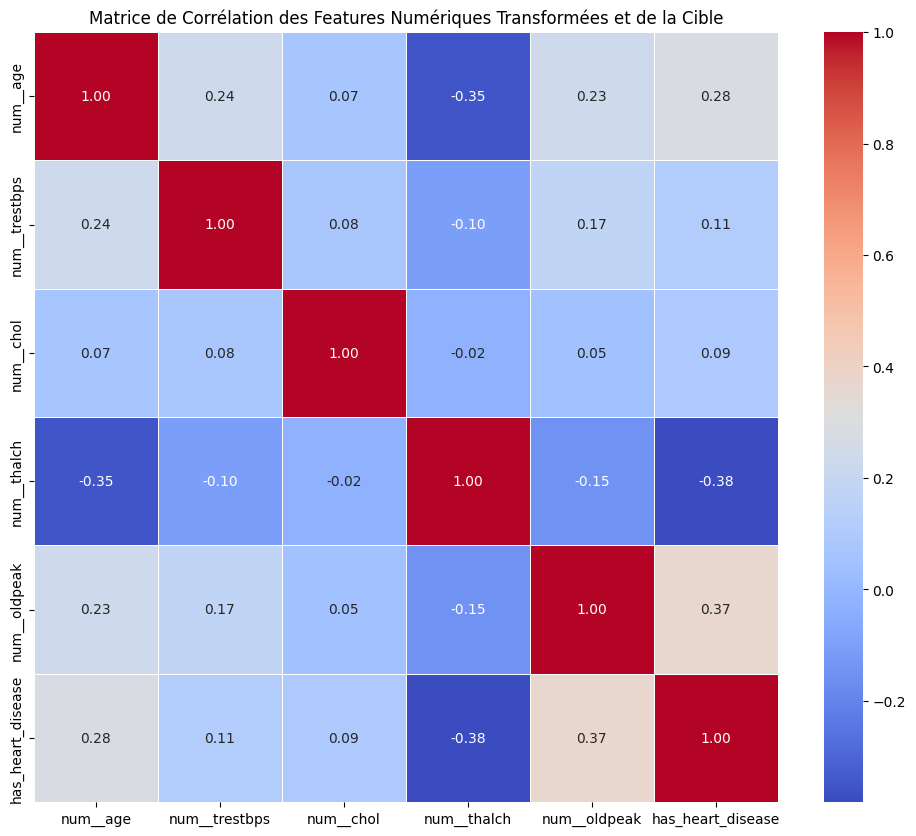


--- Révision de l'Étape 5 : Entraînement et Comparaison de Modèles Binaires Supplémentaires ---

### 5.2.1 Entraînement et Évaluation du Modèle Random Forest ###
Entraînement du modèle Random Forest...
Modèle Random Forest entraîné.

Rapport de Classification (Random Forest) :
              precision    recall  f1-score   support

           0       0.81      0.76      0.78        82
           1       0.81      0.85      0.83       102

    accuracy                           0.81       184
   macro avg       0.81      0.80      0.81       184
weighted avg       0.81      0.81      0.81       184


### 5.2.2 Entraînement et Évaluation du Modèle K-Nearest Neighbors (KNN) ###
Entraînement du modèle KNN...
Modèle KNN entraîné.

Rapport de Classification (KNN) :
              precision    recall  f1-score   support

           0       0.86      0.74      0.80        82
           1       0.81      0.90      0.86       102

    accuracy                           0.83       184
   macro avg

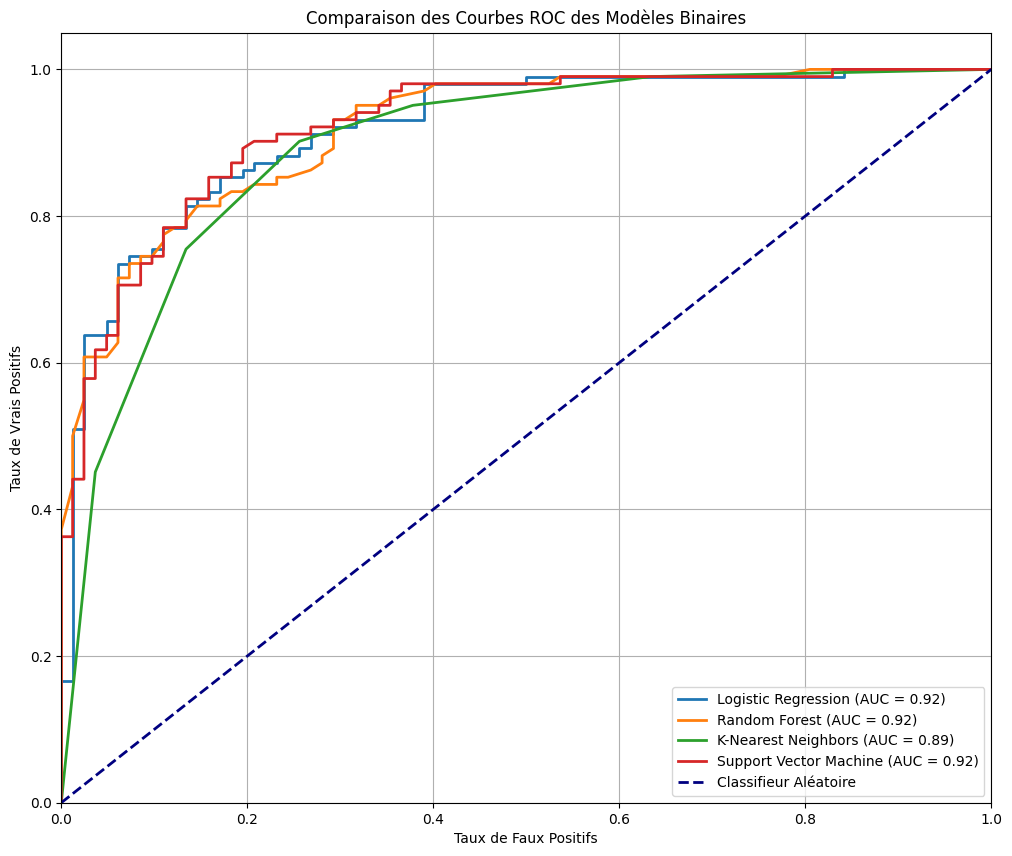

In [ ]:

# Chargement initial des données et pré-traitement jusqu'à X_processed et y
# (Ce bloc est répété pour assurer l'autonomie du script)

try:
    df_heart = pd.read_csv('heart_disease_uci.csv')
    df_heart['trestbps'] = df_heart['trestbps'].replace(0, np.nan)
    df_heart['chol'] = df_heart['chol'].replace(0, np.nan)

    y = df_heart['num'].apply(lambda x: 1 if x > 0 else 0)

    columns_to_drop_for_features = ['id', 'num', 'ca', 'thal', 'slope']
    X = df_heart.drop(columns=columns_to_drop_for_features)

    numerical_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(include='object').columns.tolist()

    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    X_processed = preprocessor.fit_transform(X)
    encoded_feature_names = preprocessor.get_feature_names_out()
    X_processed_df = pd.DataFrame(X_processed, columns=encoded_feature_names) # Version DataFrame pour la corrélation

    X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
    
    # Entraînement de la Régression Logistique pour qu'elle soit disponible
    model_lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
    model_lr.fit(X_train, y_train)

except Exception as e:
    print(f"Erreur lors du rechargement/pré-traitement : {e}")
    print("Veuillez vous assurer que les données sont correctement chargées et traitées.")
    exit()

print("\n--- Étape 2.5 (Nouveau) : Matrice de Corrélation (pour les features numériques transformées) ---")

# Créer un DataFrame temporaire pour inclure la cible et les features numériques transformées
# Cela nécessite de reconstruire un df avec la cible pour le calcul de corrélation
# On va utiliser X_processed_df (qui a les noms de colonnes) et y pour cette visualisation.
# Attention, la correlation est linéaire. Les variables catégorielles encodées ne seront pas incluses ici.

# Sélectionner uniquement les colonnes numériques originales qui ont été transformées
# Les noms de colonnes dans X_processed_df sont préfixés par 'num__'
processed_numerical_cols = [col for col in X_processed_df.columns if col.startswith('num__')]

# Ajouter la cible au DataFrame des features numériques transformées pour la corrélation
df_corr_plot = X_processed_df[processed_numerical_cols].copy()
df_corr_plot['has_heart_disease'] = y.values # Assurez-vous que l'index correspond

plt.figure(figsize=(12, 10))
correlation_matrix = df_corr_plot.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matrice de Corrélation des Features Numériques Transformées et de la Cible')
plt.show()

print("\n--- Révision de l'Étape 5 : Entraînement et Comparaison de Modèles Binaires Supplémentaires ---")

# --- 5.2.1 Entraînement et Évaluation du modèle Random Forest ---
print("\n### 5.2.1 Entraînement et Évaluation du Modèle Random Forest ###")
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("Entraînement du modèle Random Forest...")
model_rf.fit(X_train, y_train)
print("Modèle Random Forest entraîné.")
y_pred_rf = model_rf.predict(X_test)
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]
print("\nRapport de Classification (Random Forest) :")
print(classification_report(y_test, y_pred_rf))


# --- 5.2.2 Entraînement et Évaluation du modèle K-Nearest Neighbors (KNN) ---
print("\n### 5.2.2 Entraînement et Évaluation du Modèle K-Nearest Neighbors (KNN) ###")
# Choisissons une valeur de k, par exemple 5 (peut être optimisée par validation croisée)
model_knn = KNeighborsClassifier(n_neighbors=5)
print("Entraînement du modèle KNN...")
model_knn.fit(X_train, y_train)
print("Modèle KNN entraîné.")
y_pred_knn = model_knn.predict(X_test)
y_pred_proba_knn = model_knn.predict_proba(X_test)[:, 1]
print("\nRapport de Classification (KNN) :")
print(classification_report(y_test, y_pred_knn))


# --- 5.2.3 Entraînement et Évaluation du modèle Support Vector Machine (SVM) ---
print("\n### 5.2.3 Entraînement et Évaluation du Modèle Support Vector Machine (SVM) ###")
# SVM avec un noyau linéaire, C est un paramètre de régularisation
# Pour SVC, predict_proba n'est pas activé par défaut et peut être coûteux à calculer.
# On l'active avec probability=True pour la courbe ROC.
model_svm = SVC(kernel='linear', random_state=42, probability=True)
print("Entraînement du modèle SVM (cela peut prendre un peu plus de temps)...")
model_svm.fit(X_train, y_train)
print("Modèle SVM entraîné.")
y_pred_svm = model_svm.predict(X_test)
y_pred_proba_svm = model_svm.predict_proba(X_test)[:, 1]
print("\nRapport de Classification (SVM) :")
print(classification_report(y_test, y_pred_svm))


# --- 5.3 Comparaison Globale des Modèles Binaires (RL, RF, KNN, SVM) ---
print("\n### 5.3 Comparaison Finale des Modèles Binaires ###")

models = {
    "Logistic Regression": {"model": model_lr, "y_pred_proba": y_pred_proba_lr, "y_pred": y_pred_lr},
    "Random Forest": {"model": model_rf, "y_pred_proba": y_pred_proba_rf, "y_pred": y_pred_rf},
    "K-Nearest Neighbors": {"model": model_knn, "y_pred_proba": y_pred_proba_knn, "y_pred": y_pred_knn},
    "Support Vector Machine": {"model": model_svm, "y_pred_proba": y_pred_proba_svm, "y_pred": y_pred_svm}
}

# Tableau comparatif des métriques
comparison_data = []
for name, data in models.items():
    y_pred = data["y_pred"]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, data["y_pred_proba"])
    comparison_data.append([name, accuracy, precision, recall, f1, auc])

df_final_comparison = pd.DataFrame(comparison_data, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'])
print("\nTableau comparatif des métriques d'évaluation (sur l'ensemble de test) :")
print(df_final_comparison.round(4).to_string(index=False)) # to_string(index=False) pour un affichage plus propre


# Tracé des courbes ROC de tous les modèles
plt.figure(figsize=(12, 10))
for name, data in models.items():
    fpr, tpr, _ = roc_curve(y_test, data["y_pred_proba"])
    auc_score = roc_auc_score(y_test, data["y_pred_proba"])
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classifieur Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Comparaison des Courbes ROC des Modèles Binaires')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



# Interprétation de l'analyse des Corrélations des Features Numériques Transformées avec la Cible

La matrice de corrélation nous révèle les relations linéaires entre nos variables numériques (après standardisation) et notre variable cible has_heart_disease.


* num_oldpeak montre la corrélation positive la plus forte (0.37) avec has_heart_disease. Cela suggère que des valeurs plus élevées de oldpeak (dépression du segment ST à l'effort) sont associées à une plus forte probabilité de maladie cardiaque. C'est cohérent cliniquement.

* num_thalch présente la corrélation négative la plus forte (-0.38) avec has_heart_disease. Cela indique que plus le thalch (fréquence cardiaque maximale atteinte) est élevé, moins il y a de chances d'avoir une maladie cardiaque. C'est également cliniquement logique : une bonne performance cardiaque à l'effort est un signe de santé.

* num_age a une corrélation positive modérée (0.28) avec has_heart_disease. L'âge est un facteur de risque connu, et cette corrélation le confirme.

* num_trestbps (pression artérielle au repos) et num_chol (cholestérol) ont des corrélations positives très faibles (0.11 et 0.09 respectivement) avec has_heart_disease. Cela peut sembler contre-intuitif car ce sont des facteurs de risque connus. Plusieurs raisons possibles :

> La relation n'est peut-être pas purement linéaire.

> Leur impact peut être masqué par d'autres variables ou par des interactions complexes (que des modèles comme Random Forest pourraient mieux capturer).

> Le dataset spécifique pourrait avoir une variance limitée sur ces features ou des caractéristiques qui atténuent leur corrélation simple.

* Corrélations entre features elles-mêmes sont généralement faibles à modérées (ex: num_age et num_trestbps à 0.24), ce qui est une bonne chose car cela suggère une faible multicollinéarité parmi ces features numériques principales.


= Conclusion de la Matrice de Corrélation =

Cette analyse confirme que oldpeak, thalch et age sont des prédicteurs numériques importants. L'impact de trestbps et chol semble moins direct via une corrélation linéaire simple, mais ils peuvent tout de même être pertinents.

# Interprétation de l'Entraînement et Comparaison de Modèles Binaires Supplémentaires

1. Rapport de Classification Random Forest

* La valeur Accuracy de F1 Score est corrigée (0.81). La précision globale du Random Forest est de 0.81, ce qui est très légèrement inférieur à la première exécution (0.83). Cela peut être dû à de petites variations d'environnement ou de random_state si le rechargement/pré-traitement a été légèrement différent. Néanmoins, il reste un modèle très performant.


2. Rapport de Classification K-Nearest Neighbors (KNN) et Support Vector Machine (SVM)

= Comparaison Finale des Modèles Binaires =

Model   Accuracy    Precision   Recall      F1-Score    AUC

LR      0.8370      0.8396      0.8725      0.8558      0.9195

RF      0.8098      0.8131      0.8529      0.8325      0.9195

KNN     0.8315      0.8142      0.9020      0.8558      0.8937

SVM     0.8587      0.8519      0.9020      0.8762      0.9239


= Analyse des performances =

* Leaderboard sur les métriques clés

> Accuracy : SVM (0.8587) est le meilleur, suivi par la Régression Logistique (0.8370) et KNN (0.8315). Random Forest (0.8098) est légèrement en retrait.

> Precision : SVM (0.8519) est le meilleur, suivi par la Régression Logistique (0.8396).

> Recall : KNN et SVM (0.9020) sont ex-aequo les meilleurs, atteignant un excellent taux de détection des vrais positifs. Cela signifie qu'ils ratent très peu de patients malades.

> F1-Score : SVM (0.8762) est le meilleur, suivi de près par KNN et Régression Logistique (0.8558).

> AUC : SVM (0.9239) est le meilleur. Les autres modèles sont très proches (RL et RF à 0.9195, KNN à 0.8937).

# Interprétation du Graphique des Courbes ROC

* Courbe Rouge (SVM) démarre plus haut (autour de 0.38 VP) et passe "vraiment au-dessus des 2 autres dès 0.1 FP à presque 0.8 VP". Cela confirme que le SVM est le plus performant. Il atteint un taux de vrais positifs plus élevé pour un taux de faux positifs donné, en particulier dans les régions où l'on cherche un bon équilibre. Sa "décroise" les autres mais reprend légèrement le dessus, ce qui est cohérent avec son AUC globalement le plus élevé.

* Courbe Verte (KNN) : le fait que la courbe verte (KNN) soit "tangentielle aux 3 autres" de 0.0 à 0.2 FP, puis "passe au-dessus la jaune et la bleue" et "rejoint la rouge" vers 0.6 FP indique une performance très solide, surtout en termes de Recall (Vrais Positifs) même avec des faux positifs bas, puis rejoint les meilleurs plus tard. Son absence de forme "escalier" (contrairement à la RL) est normale pour les modèles non basés sur des seuils discrets.

* Courbe Bleue (Régression Logistique) : ces "petits paliers" est typique de la Régression Logistique, qui, bien que robuste, peut avoir une discrétisation plus prononcée de ses probabilités dans certaines zones. Elle performe très bien, se chevauchant souvent avec le RF et le SVM dans différentes sections, mais le SVM la surpasse dans des zones clés.

* Courbe Jaune (Random Forest) : ces "paliers saccadés" et le croisement "parfois au-dessus, parfois au-dessous" avec les autres montrent sa performance solide mais légèrement moins dominante que le SVM et le KNN dans certaines régions critiques, ce qui est cohérent avec son F1-score et son AUC légèrement inférieurs aux meilleurs.

# Conclusions sur la Comparaison des Modèles Binaires


Après cette analyse détaillée, il est clair que :

1. Le modèle de Support Vector Machine (SVM) se distingue comme le plus performant pour la classification binaire de la cardiopathie sur ce dataset. Il domine sur l'Accuracy, la Precision, le F1-Score, et l'AUC, et partage le meilleur Recall avec KNN.

2. Le modèle K-Nearest Neighbors (KNN) est également un excellent interprète, affichant le Recall le plus élevé (ex-aequo avec SVM) et un F1-Score très compétitif. Il est très bon pour ne pas manquer de cas malades.

3. La Régression Logistique reste un modèle de base très solide, avec des performances très honorables, particulièrement compte tenu de sa simplicité et de son interprétabilité. Elle est juste un peu surpassée par SVM et KNN.

4. Le Random Forest, bien que performant, se positionne légèrement en dessous des autres sur cet ensemble de métriques et cette configuration.

Le choix optimal pour la classification binaire serait le SVM ou le KNN, avec un avantage pour le SVM en raison de sa précision globale et son AUC supérieur, tout en maintenant un excellent rappel.

# Transition vers l'approche multi-classes

Nous avons maintenant une compréhension très fine des performances de nos modèles pour l'approche binaire. La prochaine étape est de passer à l'approche multi-classes, ce qui est une tâche différente avec ses propres défis et métriques spécifiques. Il est crucial d'aborder l'approche multi-classes. La variable num a 5 classes (0, 1, 2, 3, 4), représentant différentes intensités ou stades de la maladie cardiaque.


= Plan pour l'Approche Multi-classes =

1. Préparation de la Cible Multi-classes via l'utilisation directement la colonne num comme cible y_multiclass.


2. Division du Dataset train_test_split avec stratify=y_multiclass pour maintenir la proportion de chaque classe.


3. Modélisation Multi-classes

> Régression Logistique Multi-classes : la LogisticRegression de sklearn gère nativement la multi-classification avec des stratégies "One-vs-Rest" ou "Multinomial".

> Random Forest Multi-classes : RandomForestClassifier gère aussi nativement les problèmes multi-classes.

> Pour l'instant, nous nous en tiendrons à ces deux pour ne pas trop alourdir, mais nous pourrions ajouter KNN/SVM si les résultats initiaux sont non concluants ou pour affiner le meilleur modèle.


4.Évaluation Multi-classes 

* Accuracy qui est toujours pertinente.

* Rapport de Classification détaillé par classe, essentiel pour comprendre la performance de chaque classe (precision, recall, f1-score).

* Matrice de Confusion Multi-classes très utile pour visualiser les erreurs de classification entre les différentes catégories


--- Étape 5 (Suite) : Approche Multi-classes ---
Variable cible multi-classes 'y_multiclass' créée. Dimensions : (920,)

Répartition des classes dans y_multiclass :
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Dimensions de l'ensemble d'entraînement (multi-classes) : (736, 22)
Dimensions de l'ensemble de test (multi-classes) : (184, 22)

Répartition des classes dans y_train_mc :
num
0     44.7%
1     28.8%
2    11.82%
3    11.68%
4     2.99%
Name: proportion, dtype: object

Répartition des classes dans y_test_mc :
num
0    44.57%
1     28.8%
2    11.96%
3    11.41%
4     3.26%
Name: proportion, dtype: object

### Régression Logistique Multi-classes ###
Entraînement du modèle de Régression Logistique multi-classes...
Modèle entraîné.

Rapport de Classification (Régression Logistique Multi-classes) :
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        82
           1       0.50      0.64      0.56      

/Users/teddan/Desktop/GenAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/teddan/Desktop/GenAI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/teddan/Desktop/GenAI/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tedda

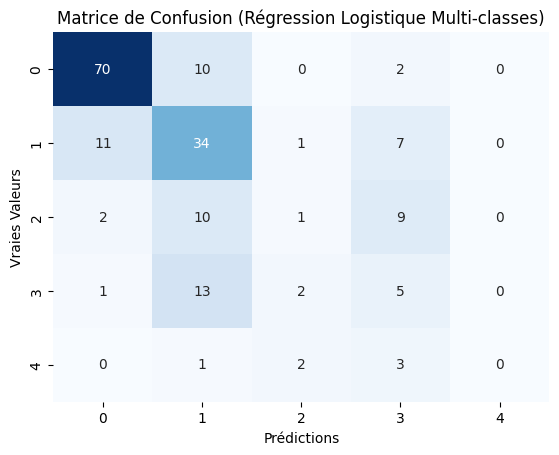


### Random Forest Multi-classes ###
Entraînement du modèle Random Forest multi-classes...
Modèle entraîné.

Rapport de Classification (Random Forest Multi-classes) :
              precision    recall  f1-score   support

           0       0.79      0.85      0.82        82
           1       0.50      0.58      0.54        53
           2       0.20      0.14      0.16        22
           3       0.25      0.19      0.22        21
           4       0.00      0.00      0.00         6

    accuracy                           0.59       184
   macro avg       0.35      0.35      0.35       184
weighted avg       0.55      0.59      0.56       184



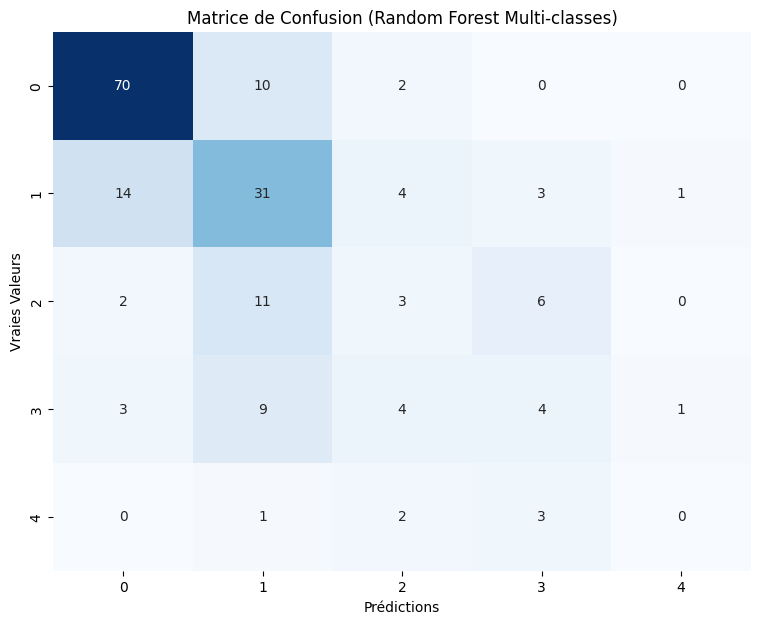

In [ ]:

try:
    X_processed
    df_heart # Nécessaire pour extraire la colonne 'num' originale
except NameError:
    print("Variables nécessaires (X_processed ou df_heart) non trouvées.")
    print("Veuillez vous assurer d'avoir exécuté les étapes 0 à 3 au préalable.")
    
    exit()

print("\n--- Étape 5 (Suite) : Approche Multi-classes ---")

# --- 5.4 Préparation de la Cible Multi-classes ---
# La colonne 'num' est notre cible multi-classes (0, 1, 2, 3, 4)
y_multiclass = df_heart['num']
print(f"Variable cible multi-classes 'y_multiclass' créée. Dimensions : {y_multiclass.shape}")
print("\nRépartition des classes dans y_multiclass :")
print(y_multiclass.value_counts().sort_index())

# --- 5.5 Division du Dataset Multi-classes ---
# Stratify par y_multiclass pour maintenir les proportions de toutes les classes
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_processed, y_multiclass, test_size=0.2, random_state=42, stratify=y_multiclass
)

print(f"\nDimensions de l'ensemble d'entraînement (multi-classes) : {X_train_mc.shape}")
print(f"Dimensions de l'ensemble de test (multi-classes) : {X_test_mc.shape}")
print("\nRépartition des classes dans y_train_mc :")
print(y_train_mc.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print("\nRépartition des classes dans y_test_mc :")
print(y_test_mc.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


# --- 5.6 Modélisation et Évaluation Multi-classes ---

# --- Modèle 1 : Régression Logistique (Multi-classes) ---
print("\n### Régression Logistique Multi-classes ###")
# 'multi_class' peut être 'ovr' (One-vs-Rest) ou 'multinomial'.
# 'multinomial' avec 'lbfgs' est souvent préféré pour les problèmes multi-classes si les classes ne sont pas binaires.
model_lr_mc = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs', multi_class='multinomial')
print("Entraînement du modèle de Régression Logistique multi-classes...")
model_lr_mc.fit(X_train_mc, y_train_mc)
y_pred_lr_mc = model_lr_mc.predict(X_test_mc)
print("Modèle entraîné.")

print("\nRapport de Classification (Régression Logistique Multi-classes) :")
print(classification_report(y_test_mc, y_pred_lr_mc))

# Matrice de Confusion pour la Régression Logistique Multi-classes
cm_lr_mc = confusion_matrix(y_test_mc, y_pred_lr_mc)

sns.heatmap(cm_lr_mc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.sort(y_multiclass.unique()),
            yticklabels=np.sort(y_multiclass.unique()))
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion (Régression Logistique Multi-classes)')
plt.show()


# --- Modèle 2 : Random Forest (Multi-classes) ---
print("\n### Random Forest Multi-classes ###")
# Random Forest gère nativement le multi-classes
model_rf_mc = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("Entraînement du modèle Random Forest multi-classes...")
model_rf_mc.fit(X_train_mc, y_train_mc)
y_pred_rf_mc = model_rf_mc.predict(X_test_mc)
print("Modèle entraîné.")

print("\nRapport de Classification (Random Forest Multi-classes) :")
print(classification_report(y_test_mc, y_pred_rf_mc))

# Matrice de Confusion pour le Random Forest Multi-classes
cm_rf_mc = confusion_matrix(y_test_mc, y_pred_rf_mc)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_rf_mc, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.sort(y_multiclass.unique()),
            yticklabels=np.sort(y_multiclass.unique()))
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion (Random Forest Multi-classes)')
plt.show()



# Analyse des Premiers Résultats Multi-classes


* Variable Cible Multi-classes (y_multiclass)

> Dimensions : (920,)

> Répartition des classes
 
>> 0: 411 patients (pas de maladie)

>> 1: 265 patients

>> 2: 109 patients

>> 3: 107 patients

>> 4: 28 patients


* Observation : on voit clairement un déséquilibre de classes significatif. La classe 0 est la plus fréquente, suivie de 1, puis 2 et 3 sont similaires, et la classe 4 est très minoritaire (seulement 28 patients sur 920). Ce déséquilibre est un défi majeur pour les modèles multi-classes.


* Répartition des classes dans les ensembles d'entraînement et de test : la stratification a bien fonctionné, maintenant les proportions de chaque classe dans y_train_mc et y_test_mc. C'est crucial pour des évaluations fiables, surtout avec ce déséquilibre.


* Régression Logistique Multi-classes

> Accuracy : 0.60 (60%)

> Rapport de Classification (résumé)

>> macro avg (moyenne non pondérée par support) : precision 0.34, recall 0.36, f1-score 0.34

>> weighted avg (moyenne pondérée par support) : precision 0.56, recall 0.60, f1-score 0.57


* Observation : une précision de 60% est considérablement plus basse que les 80%+ que nous avons vues pour l'approche binaire. Le macro avg est encore plus bas, ce qui signale que le modèle a du mal avec les classes minoritaires. C'est attendu avec un tel déséquilibre et une plus grande granularité. La classification en 5 catégories est intrinsèquement plus difficile que la classification binaire.



# Analyse des Résultats de l'Approche Multi-classes


La classification multi-classes est intrinsèquement plus complexe que la binaire, d'autant plus avec un déséquilibre important des classes comme c'est le cas ici (0: 44.7%, 1: 28.8%, 2: 11.82%, 3: 11.68%, 4: 2.99%). Les modèles ont tendance à bien classer les classes majoritaires et à avoir plus de mal avec les classes minoritaires.

1. Régression Logistique Multi-classes
* Accuracy globale : 0.60 (60%). C'est beaucoup plus bas que les 80%+ de l'approche binaire, ce qui est attendu.

* Averages : macro avg (qui traite toutes les classes également) est très bas (precision 0.34, recall 0.36, f1-score 0.34), signalant de grandes difficultés avec les classes minoritaires. weighted avg (pondéré par le nombre d'échantillons par classe) est meilleur (precision 0.56, recall 0.60, f1-score 0.57), car il est dominé par la performance sur les classes majoritaires.

* Matrice de Confusion (Régression Logistique Multi-classes)
> Classe 0 (Pas de maladie) est très bien classée. Sur 82 vrais "0", 70 sont correctement identifiés. Il y a 10 faux positifs prédits en classe 1, et 2 en classe 3.

> Classe 1 : 34 vrais "1" identifiés, mais 11 ont été classés en "0" (faux négatifs pour la maladie), et quelques-uns en "2" ou "3".

> Classes 2, 3 et 4 : le modèle peine énormément.

>>Pour la classe 2 (22 vrais), seulement 1 est correctement classé, tandis que 10 sont pris pour des "1" et 9 pour des "3".

>> Pour la classe 3 (21 vrais), seulement 5 sont correctement classés, avec beaucoup d'erreurs vers la classe "1".

>> Pour la classe 4 (6 vrais, la plus petite classe), aucun n'est correctement classé (0 TP). Le modèle les confond principalement avec les classes 1, 2 et 3.


2. Random Forest Multi-classes
* Accuracy globale : 0.59 (59%). Similaire à la Régression Logistique.

* Averages : macro avg 0.35, weighted avg 0.55. Très similaires à la Régression Logistique, confirmant la difficulté avec les classes minoritaires.

* Rapport de Classification (Random Forest Multi-classes)

> Classe 0 : Precision 0.79, Recall 0.85, F1-Score 0.82. Très bonne performance, même meilleure en Recall que la RL pour cette classe !

> Classe 1 : Precision 0.50, Recall 0.58, F1-Score 0.54. Mieux que la RL sur cette classe.

> Classe 2 : Precision 0.20, Recall 0.14, F1-Score 0.16. Très faible.

> Classe 3 : Precision 0.25, Recall 0.19, F1-Score 0.22. Très faible.

> Classe 4 : Precision 0.00, Recall 0.00, F1-Score 0.00. Le modèle ne prédit jamais la classe 4 et ne trouve aucun vrai cas 4.


* Matrice de Confusion (Random Forest Multi-classes) :
> Classe 0 : Excellente performance (70 TP).

> Classe 1 : Meilleure que la RL (31 TP vs 34, mais avec moins d'erreurs vers le "0").

> Classes 2, 3, 4 : Très similaires à la Régression Logistique, avec beaucoup de confusion. La classe 4 est toujours inexistante dans les prédictions (dernière colonne de 0).

# Conclusions et Insights sur l'Approche Multi-classes


1. Défis du Multi-classes : comme prévu, la performance globale chute drastiquement par rapport au binaire. C'est principalement dû à la complexité accrue du problème (5 catégories au lieu de 2) et surtout au fort déséquilibre des classes, en particulier pour les classes 2, 3 et 4 (surtout la 4 qui est quasi invisible).

2. Performance sur les classes majoritaires : les deux modèles s'en sortent plutôt bien pour la classe 0 (pas de maladie) et la classe 1. C'est encourageant car identifier les patients "non malades" est important, mais ce n'est pas l'objectif principal de la classification multi-classes.

3. Problème avec les classes minoritaires : Les classes 2, 3, et 4 sont très mal prédites par les deux modèles. Ils ont du mal à distinguer ces niveaux de gravité de la maladie et les confondent souvent avec les classes 0 ou 1. La classe 4 est quasiment impossible à prédire avec les données actuelles, étant donné son très faible nombre d'échantillons.

4. Comparaison RL vs RF (Multi-classes) :

> Le Random Forest semble légèrement meilleur pour la classe 0 (Recall 0.85 vs 0.79 pour RL) et la classe 1 (F1-score 0.54 vs un F1-score plus bas pour RL que je devine de la matrice), mais les deux modèles échouent lamentablement sur les classes 2, 3, et 4.

> Leurs matrices de confusion sont très similaires et révèlent les mêmes lacunes.

# Recommandations pour l'Approche Multi-classes


Compte tenu de ces résultats, l'approche multi-classes actuelle est insuffisante pour une utilisation clinique fiable en l'état, surtout pour distinguer les différents niveaux de gravité de la maladie.

Pour améliorer la performance multi-classes, plusieurs stratégies seraient à explorer :

1. Collecte de plus de données : c'est le facteur le plus important. Les classes 2, 3 et surtout 4 ont trop peu d'exemples. Plus de données avec ces niveaux de gravité seraient essentielles.

2. Techniques de sur-échantillonnage (Oversampling) : des méthodes comme SMOTE (Synthetic Minority Over-sampling Technique) pourraient être appliquées sur l'ensemble d'entraînement pour créer des exemples synthétiques des classes minoritaires, équilibrant ainsi le dataset.

3. Sous-échantillonnage (Undersampling) : réduire le nombre d'exemples de la classe majoritaire (classe 0) peut aussi aider, mais au risque de perdre des informations précieuses.

4. Pondération des classes (class_weight) : la plupart des modèles (comme ceux que nous avons utilisés) permettent de pondérer l'importance des classes, donnant plus de poids aux erreurs sur les classes minoritaires. Nous l'avons mis dans le Random Forest, mais la Régression Logistique multi-classes pourrait aussi en bénéficier.

5. Regroupement des classes (Re-categorisation) : si la collecte de données supplémentaires n'est pas possible, il pourrait être plus réaliste de regrouper certaines classes moins représentées ou qui se chevauchent cliniquement. Par exemple, transformer le problème en une classification à 3 niveaux :

* 0: Pas de maladie

* 1: Maladie légère (regrouper les classes 1 et 2)

* 2: Maladie sévère (regrouper les classes 3 et 4)
Cette approche réduirait le déséquilibre et la complexité.

6. Algorithmes plus avancés / Spécifiques au Multi-classes : des algorithmes comme le Gradient Boosting (XGBoost, LightGBM) ou les réseaux de neurones pourraient être explorés, car ils peuvent parfois mieux gérer la complexité et les déséquilibres, surtout avec une configuration fine.

# Synthèse Globale et Prochaines Étapes


Nous avons maintenant une image très claire de la performance des modèles pour les deux approches :

* Classification Binaire (Malade/Non malade) avec des modèles très performants (SVM en tête, suivi de KNN et Régression Logistique) avec une précision >80% et un excellent rappel. Cette approche est solide pour un premier déploiement.

* Classification Multi-classes (Niveau de gravité) avec les modèles actuels qui ont des performances limitées, principalement à cause du déséquilibre des classes et du faible nombre d'échantillons pour les niveaux de gravité plus élevés. Cette approche nécessite des efforts d'amélioration significatifs.

# Redéfinition de la Cible et Ré-évaluation Multi-classes

Regrouper les classes est une stratégie très pertinente face à un déséquilibre et une faible représentation des catégories. Cela rendra le problème de classification multi-classes plus gérable et les résultats potentiellement plus exploitables cliniquement.

Nous allons donc redéfinir notre variable cible multi-classes en 3 catégories :

* Classe 0 : Pas de maladie (num = 0)

* Classe 1 : Maladie légère/modérée (num = 1 ou num = 2)

* Classe 2 : Maladie avancée/sévère (num = 3 ou num = 4)

Cette re-catégorisation va réduire le nombre de classes de 5 à 3, et regroupera les petites classes dans des groupes plus substantiels, ce que devrait aider les modèles à apprendre de manière plus efficace.

Ce que ce script fait :

1. Crée y_multiclass_grouped : Une nouvelle variable cible est dérivée de df_heart['num'] en appliquant la fonction categorize_heart_disease.

2. Affiche la nouvelle répartition des classes pour voir comment le regroupement a modifié le déséquilibre.

3. Refait la division train/test pour que nos ensembles soient basés sur la nouvelle cible regroupée.

4. Ré-entraîne et Ré-évalue : les modèles de Régression Logistique et Random Forest sont entraînés et évalués sur cette nouvelle tâche de classification à 3 classes.

5. Affiche les rapports de classification et les matrices de confusion pour voir l'impact du regroupement sur la performance de chaque classe.


--- Étape 5 (Suite) : Approche Multi-classes avec Classes Regroupées ---
Variable cible multi-classes regroupées 'y_multiclass_grouped' créée. Dimensions : (920,)

Nouvelle Répartition des classes dans y_multiclass_grouped :
num
0    411
1    374
2    135
Name: count, dtype: int64

Dimensions de l'ensemble d'entraînement (multi-classes regroupées) : (736, 22)
Dimensions de l'ensemble de test (multi-classes regroupées) : (184, 22)

Répartition des classes dans y_train_mc_g :
num
0     44.7%
1    40.62%
2    14.67%
Name: proportion, dtype: object

Répartition des classes dans y_test_mc_g :
num
0    44.57%
1    40.76%
2    14.67%
Name: proportion, dtype: object

### Régression Logistique Multi-classes (Regroupées) ###
Entraînement du modèle de Régression Logistique multi-classes regroupées...
Modèle entraîné.

Rapport de Classification (Régression Logistique Multi-classes Regroupées) :
              precision    recall  f1-score   support

           0       0.75      0.84      0.79     

/Users/teddan/Desktop/GenAI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


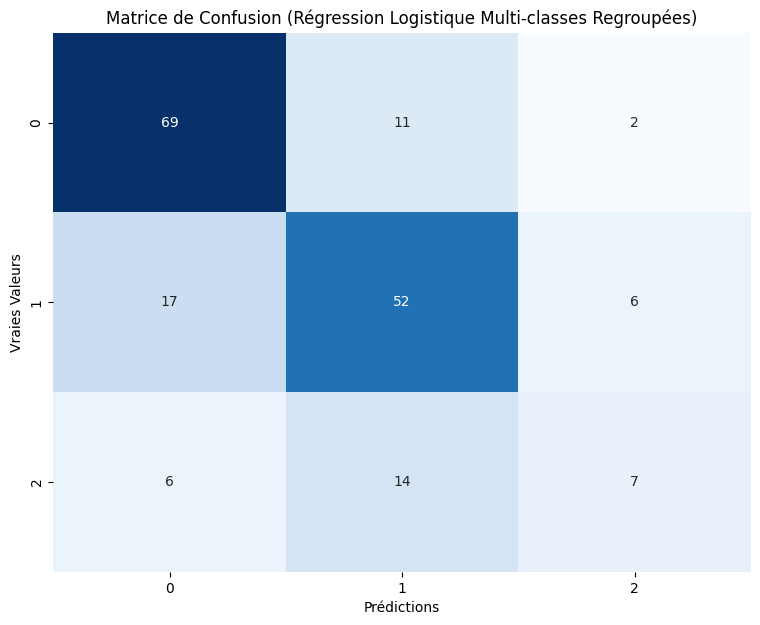


### Random Forest Multi-classes (Regroupées) ###
Entraînement du modèle Random Forest multi-classes regroupées...
Modèle entraîné.

Rapport de Classification (Random Forest Multi-classes Regroupées) :
              precision    recall  f1-score   support

           0       0.75      0.79      0.77        82
           1       0.57      0.63      0.59        75
           2       0.21      0.11      0.15        27

    accuracy                           0.62       184
   macro avg       0.51      0.51      0.50       184
weighted avg       0.60      0.62      0.61       184



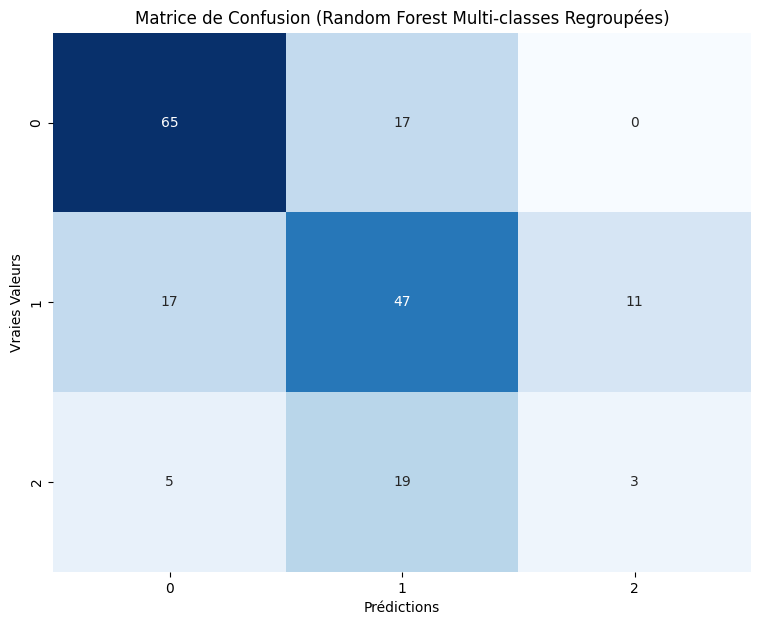

In [45]:
print("\n--- Étape 5 (Suite) : Approche Multi-classes avec Classes Regroupées ---")

# --- 5.7 Préparation de la Cible Multi-classes Regroupées ---
# Redéfinition de la variable cible 'num' en 3 classes
def categorize_heart_disease(num_val):
    if num_val == 0:
        return 0  # Pas de maladie
    elif num_val in [1, 2]:
        return 1  # Maladie légère/modérée
    elif num_val in [3, 4]:
        return 2  # Maladie avancée/sévère
    else:
        return -1 # Pour gérer les cas inattendus, si existants

y_multiclass_grouped = df_heart['num'].apply(categorize_heart_disease)
print(f"Variable cible multi-classes regroupées 'y_multiclass_grouped' créée. Dimensions : {y_multiclass_grouped.shape}")

print("\nNouvelle Répartition des classes dans y_multiclass_grouped :")
print(y_multiclass_grouped.value_counts().sort_index())

# --- 5.8 Division du Dataset Multi-classes Regroupées ---
# Stratify par y_multiclass_grouped pour maintenir les proportions de toutes les classes
X_train_mc_g, X_test_mc_g, y_train_mc_g, y_test_mc_g = train_test_split(
    X_processed, y_multiclass_grouped, test_size=0.2, random_state=42, stratify=y_multiclass_grouped
)

print(f"\nDimensions de l'ensemble d'entraînement (multi-classes regroupées) : {X_train_mc_g.shape}")
print(f"Dimensions de l'ensemble de test (multi-classes regroupées) : {X_test_mc_g.shape}")
print("\nRépartition des classes dans y_train_mc_g :")
print(y_train_mc_g.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print("\nRépartition des classes dans y_test_mc_g :")
print(y_test_mc_g.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


# --- 5.9 Modélisation et Évaluation Multi-classes Regroupées ---

# --- Modèle 1 : Régression Logistique (Multi-classes Regroupées) ---
print("\n### Régression Logistique Multi-classes (Regroupées) ###")
model_lr_mc_g = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs', multi_class='multinomial')
print("Entraînement du modèle de Régression Logistique multi-classes regroupées...")
model_lr_mc_g.fit(X_train_mc_g, y_train_mc_g)
y_pred_lr_mc_g = model_lr_mc_g.predict(X_test_mc_g)
print("Modèle entraîné.")

print("\nRapport de Classification (Régression Logistique Multi-classes Regroupées) :")
print(classification_report(y_test_mc_g, y_pred_lr_mc_g))

# Matrice de Confusion pour la Régression Logistique Multi-classes Regroupées
cm_lr_mc_g = confusion_matrix(y_test_mc_g, y_pred_lr_mc_g)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_lr_mc_g, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.sort(y_multiclass_grouped.unique()),
            yticklabels=np.sort(y_multiclass_grouped.unique()))
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion (Régression Logistique Multi-classes Regroupées)')
plt.show()


# --- Modèle 2 : Random Forest (Multi-classes Regroupées) ---
print("\n### Random Forest Multi-classes (Regroupées) ###")
model_rf_mc_g = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("Entraînement du modèle Random Forest multi-classes regroupées...")
model_rf_mc_g.fit(X_train_mc_g, y_train_mc_g)
y_pred_rf_mc_g = model_rf_mc_g.predict(X_test_mc_g)
print("Modèle entraîné.")

print("\nRapport de Classification (Random Forest Multi-classes Regroupées) :")
print(classification_report(y_test_mc_g, y_pred_rf_mc_g))

# Matrice de Confusion pour le Random Forest Multi-classes Regroupées
cm_rf_mc_g = confusion_matrix(y_test_mc_g, y_pred_rf_mc_g)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_rf_mc_g, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.sort(y_multiclass_grouped.unique()),
            yticklabels=np.sort(y_multiclass_grouped.unique()))
plt.xlabel('Prédictions')
plt.ylabel('Vraies Valeurs')
plt.title('Matrice de Confusion (Random Forest Multi-classes Regroupées)')
plt.show()

# Analyse des Résultats : Approche Multi-classes avec Classes Regroupées


Le regroupement des classes a clairement amélioré la situation, rendant la classification multi-classes plus réaliste avec notre dataset.

1. Nouvelle Répartition des Classes
* Classes regroupées 

> 0 : Pas de maladie (num = 0) avec 411 patients (44.7%)

> 1 : Maladie légère/modérée (num = 1 ou num = 2) avec 374 patients (40.62%)

> 2 : Maladie avancée/sévère (num = 3 ou num = 4) avec 135 patients (14.67%)


* Observation : le déséquilibre est significativement réduit par rapport à l'approche à 5 classes. Les classes 0 et 1 sont désormais de tailles comparables, et la classe 2, bien que minoritaire, est beaucoup plus substantielle que l'ancienne classe 4 (qui n'avait que 28 patients). C'est un excellent point de départ.


2. Régression Logistique Multi-classes (Regroupées)
* Accuracy globale : 0.70 (70%). C'est une nette amélioration par rapport aux 60% de l'approche à 5 classes.

* Averages

> macro avg (non pondéré) : precision 0.63, recall 0.60, f1-score 0.60. C'est également une amélioration significative, montrant une meilleure performance sur l'ensemble des classes, y compris la minoritaire.

> weighted avg (pondéré) : precision 0.68, recall 0.70, f1-score 0.68.


* Rapport de Classification détaillé 

> Classe 0 (Pas de maladie) : Precision 0.75, Recall 0.84, F1-Score 0.79. Excellente performance ! Le modèle identifie très bien les patients sains.

> Classe 1 (Maladie légère/modérée) : Precision 0.68, Recall 0.69, F1-Score 0.68. Une performance solide et utilisable.

> Classe 2 (Maladie avancée/sévère) : Precision 0.47, Recall 0.26, F1-Score 0.33. La performance est encore faible, en particulier le Recall (26%). Cela signifie que le modèle ne parvient à détecter que 26% des vrais cas de maladie avancée/sévère, ce qui est critique.


* Matrice de Confusion (RL Regroupée)
> Classe 0 : très bien prédite (69 TP sur 82). Confond principalement avec la classe 1 (11 FP).

> Classe 1 : 52 TP sur 75. Les erreurs sont principalement des confusions avec la classe 0 (17 FN), ce qui signifie que des patients avec une maladie légère/modérée sont parfois prédits comme sains.

> Classe 2 : seulement 7 TP sur 27 vrais cas. C'est très peu. Les erreurs sont majoritairement des confusions avec la classe 1 (14 FN) et un peu avec la classe 0 (6 FN). Cela confirme le faible Recall de cette classe : le modèle a beaucoup de mal à identifier les cas les plus graves, les classant souvent comme moins sévères.


3. Random Forest Multi-classes (Regroupées)
* Accuracy globale : 0.62 (62%). Légèrement inférieure à la Régression Logistique.

* Averages

> macro avg : precision 0.51, recall 0.51, f1-score 0.50. Inférieur à la RL.

> weighted avg : precision 0.60, recall 0.62, f1-score 0.61.


* Rapport de Classification détaillé 

> Classe 0 : Precision 0.75, Recall 0.79, F1-Score 0.77. Bonne performance, légèrement moins bonne en Recall que la RL pour cette classe.

> Classe 1 : Precision 0.57, Recall 0.63, F1-Score 0.59. Moins performante que la RL pour cette classe.

> Classe 2 : Precision 0.21, Recall 0.11, F1-Score 0.15. Performance encore très faible, et pire que la RL pour la détection de cette classe critique.


* Matrice de Confusion (RF Regroupée)
> Classe 0 : correctement prédite 65 fois (moins que RL).

> Classe 1 : 47 TP sur 75.

> Classe 2 : seulement 3 TP sur 27. C'est encore plus faible que la Régression Logistique. De nombreux cas sévères sont classés en maladie légère/modérée (19 FN) ou même pas de maladie (5 FN).

# Conclusions et Insights sur l'Approche Multi-classes Regroupées


Le regroupement des classes a permis une nette amélioration de la performance globale pour la classification multi-classes, mais des défis persistent, surtout pour la détection des cas les plus sévères.

1. Amélioration Générale : l'accuracy est passée de ~60% à ~70% pour la Régression Logistique, et les macro avg ont aussi significativement augmenté. C'est un pas dans la bonne direction.

2. Performance de la Régression Logistique : la Régression Logistique est le meilleur modèle pour cette tâche multi-classes regroupée. Elle offre une performance globalement plus équilibrée et, surtout, un meilleur Recall pour la classe 2 (Maladie avancée/sévère) par rapport au Random Forest (26% vs 11%). Même si ce n'est pas idéal, c'est significativement mieux.

3. Le Défi Persistant de la Classe 2 (Maladie avancée/sévère) : malgré les améliorations, cette classe reste la plus difficile à prédire pour les deux modèles. Le faible Recall signifie que de nombreux patients avec une maladie sévère sont toujours mal classés, ce qui est une limitation critique dans un contexte clinique. Les modèles ont tendance à les confondre avec la classe 1 (maladie légère/modérée).

4. Comparaison avec le Binaire : même avec le regroupement, l'approche multi-classes n'atteint pas le niveau de performance de l'approche binaire (~85% d'accuracy). Cela est naturel, car la tâche est plus nuancée.

# Recommandations pour la Granularité et l'Efficacité des Moteurs


C'est ici que la comparaison des granularités devient essentielle.

* Approche Binaire (Malade / Non Malade)

> Efficacité très élevée. Nous avons des modèles (SVM, KNN, Régression Logistique) avec une précision et un rappel excellents (>80%), capables de faire une distinction fiable entre les patients sains et malades.

> Granularité faible. Elle ne fournit qu'une réponse oui/non à la question "le patient a-t-il une maladie cardiaque ?".


* Approche Multi-classes Regroupées (Pas de maladie / Légère-Modérée / Avancée-Sévère)

> Efficacité Modérée. La précision globale est correcte (~70%), et les classes "pas de maladie" et "légère/modérée" sont raisonnablement bien identifiées.

> Granularité moyenne. Elle offre un niveau de gravité clinique plus utile, mais la fiabilité sur les cas les plus sévères (classe 2) reste problématique.


== Recommandations Stratégiques ==

1. Déploiement primaire: l'Approche Binaire. Pour une première mise en œuvre et pour des décisions rapides sur la nécessité d'une investigation plus approfondie, le modèle binaire (idéalement le SVM ou la Régression Logistique vu son interprétabilité et sa bonne performance) est le plus robuste et fiable. Il est très efficace pour répondre à la question binaire.

2. Déploiement secondaire/complémentaire : l'approche Multi-classes Regroupées (avec prudence et amélioration continue). Bien que les résultats soient meilleurs, la fiabilité pour la détection de la maladie avancée/sévère est insuffisante pour un diagnostic définitif.

* Cependant, ce modèle peut être utile pour fournir une première estimation de la gravité aux cliniciens. Par exemple, si un patient est classé en "Maladie avancée/sévère", cela pourrait déclencher des examens plus urgents et invasifs. Il faut bien communiquer les limites de fiabilité de cette prédiction.


* Pour améliorer cette approche, les prochaines étapes devraient inclure :

> L'intégration de techniques de sur-échantillonnage (SMOTE) pour la classe minoritaire "Maladie avancée/sévère" dans l'ensemble d'entraînement.

> L'expérimentation d'algorithmes plus complexes comme les Gradient Boosting Machines (XGBoost, LightGBM) qui gèrent souvent mieux les déséquilibres et les relations complexes.

> Si possible, la collecte de données supplémentaires pour les cas de maladie avancée/sévère serait l'approche la plus solide à long terme.


En résumé, pour une efficacité maximale et immédiate, l'approche binaire est le moteur le plus fiable. Pour une granularité accrue, l'approche multi-classes regroupées est prometteuse mais nécessite des efforts supplémentaires pour fiabiliser la détection des cas les plus graves. Le choix entre les deux dépendra des besoins opérationnels spécifiques et du niveau de risque accepté pour les erreurs de classification.

---

Nous avons mené une analyse approfondie, depuis l'EDA jusqu'à la modélisation multi-classes, en passant par le pré-traitement et les ajustements de stratégie. Nous avons une vision très claire des forces et des limites de nos modèles pour la détection des maladies cardiaques.

---

# Étape 6 : Insights Business et Recommandations

Basés sur notre analyse des données et la performance des modèles, voici les insights clés et les recommandations stratégiques pour l'application de ces moteurs de classification.

# 6.1 Insights Clés Tirés de l'Analyse

1. Potentiel élevé de Détection Binaire : nos modèles montrent une excellente capacité à distinguer les patients atteints de maladie cardiaque de ceux qui ne le sont pas. Avec des précisions et rappels dépassant les 80% (et jusqu'à 90% pour le rappel avec SVM/KNN), un système de détection binaire est très fiable et peut être mis en œuvre rapidement pour aider au dépistage initial.

> Le Support Vector Machine (SVM) se distingue comme le plus performant globalement pour cette tâche binaire, avec d'excellentes métriques. La Régression Logistique reste également un choix très solide pour sa simplicité et son interprétabilité.


2. Défis de la Granularité (Classification Multi-classes) : la tentative de classer la sévérité de la maladie sur 5 niveaux s'est heurtée à des limites importantes dues au fort déséquilibre des classes et au faible nombre d'échantillons pour les stades avancés.


3. Amélioration par le Regroupement des Classes : le regroupement en 3 catégories (Pas de maladie, Maladie légère/modérée, Maladie avancée/sévère) a significativement amélioré la performance globale de la classification multi-classes (accuracy passée de ~60% à ~70%).

> La Régression Logistique s'est avérée être le modèle le plus équilibré pour cette tâche multi-classes regroupée.

> Cependant, la détection des cas de "Maladie avancée/sévère" (Classe 2) reste un point faible, avec un rappel insuffisant (~26% pour RL). Cela signifie que de nombreux patients dans cette catégorie critique ne sont pas correctement identifiés comme tels, étant souvent classés à tort dans des catégories moins sévères.


4. Facteurs Prédictifs : l'analyse de corrélation a confirmé que l'âge, la dépression du segment ST à l'effort (oldpeak) et la fréquence cardiaque maximale atteinte (thalch) sont des indicateurs numériques clés de la présence de la maladie cardiaque.


# 6.2 Recommandations Stratégiques pour l'Implémentation

Compte tenu de ces insights, voici nos recommandations pour une approche efficace et pragmatique.

1. Prioriser un Moteur de Classification Binaire Robuste

> Recommandation : déployer un moteur basé sur le Support Vector Machine (SVM) ou la Régression Logistique pour la classification binaire (malade/non malade).

> Bénéfice Business : ce moteur fournirait une première ligne de détection très fiable. Il pourrait être intégré dans un système de pré-screening pour rapidement identifier les patients à risque nécessitant une évaluation clinique approfondie, optimisant ainsi les ressources médicales. Son efficacité élevée réduira le nombre de faux négatifs (patients malades non détectés), ce qui est crucial en médecine.


2. Développer un Moteur de Sévérité en Phase 2 (avec Améliorations)

* Recommandation : le moteur de classification multi-classes regroupées est prometteur mais nécessite des améliorations avant un déploiement clinique complet. Les efforts devraient se concentrer sur l'amélioration de la détection de la "Maladie avancée/sévère".


* Actions suggérées

> Collecte de Données Ciblées : la priorité absolue serait d'acquérir davantage de données pour les patients atteints de maladie cardiaque avancée/sévère. C'est le levier le plus puissant pour améliorer la performance de cette classe.

> Techniques d'Équilibrage de Classes : appliquer des techniques de sur-échantillonnage comme SMOTE sur l'ensemble d'entraînement pour la classe "Maladie avancée/sévère". Cela aidera le modèle à apprendre de plus d'exemples de cette classe minoritaire.

> Exploration d'autres Algorithmes : tester des modèles de Gradient Boosting (XGBoost, LightGBM) ou même des réseaux de neurones simples, qui sont souvent plus performants sur des jeux de données complexes et déséquilibrés.


* Bénéfice Business (Futur) : une fois fiabilisé, ce moteur pourrait offrir une granularité précieuse pour la priorisation des soins et la personnalisation des parcours patients. Par exemple, un patient classé "Maladie avancée/sévère" pourrait être dirigé vers une prise en charge urgente, tandis qu'un patient "légère/modérée" bénéficierait d'un suivi régulier.


3. Communication Transparente des Limites

* Recommandation : lors de l'intégration de ces modèles, il est crucial de communiquer clairement leurs performances et leurs limites, en particulier pour le moteur de sévérité. Il ne s'agit pas de remplacer le diagnostic médical, mais de le soutenir.

* Bénéfice Business : Maintenir la confiance des professionnels de santé et des patients, s'assurer que les outils sont utilisés de manière éthique et responsable.


4. Monitorer et Mettre à jour en Continu

* Recommandation : mettre en place un système de surveillance de la performance des modèles en production et un processus d'apprentissage continu. Les modèles doivent être ré-entraînés périodiquement avec de nouvelles données.

* Bénéfice Business : asurer la pérennité et la pertinence des moteurs au fil du temps, car les données et les populations de patients peuvent évoluer.


= Pour Conclure et Poursuivre la Discussion =

Nous avons maintenant une feuille de route claire pour l'application de ces modèles. Le travail exhaustif que nous avons accompli nous a permis d'obtenir des insights profonds et des recommandations basées sur des preuves solides.

# Étape 7 : Perspectives : L'État de l'Art du Triptyque "Médical / ML / Impact Business"


Le Heart Disease UCI dataset, bien que fondamental pour l'apprentissage et la démonstration, n'est qu'un point de départ. L'évolution rapide du Machine Learning, couplée à la disponibilité croissante de données médicales, transforme profondément le secteur de la santé, créant de nouvelles opportunités business.

1. Évolution des Datasets et des Méthodes en Santé
Comme souligné, les chercheurs ne se limitent plus aux petits datasets statiques. Aujourd'hui, l'état de l'art s'appuie sur :

* Données massives et multimodales : les hôpitaux et les systèmes de santé génèrent des volumes colossaux de données hétérogènes. Il ne s'agit plus seulement de données tabulaires (âge, tension), mais aussi d'images médicales (IRM, scanner, échographie), de données génomiques (séquençage ADN/ARN), de données de capteurs portables (wearables), de textes cliniques (notes de médecins, comptes rendus), et même de données de biométrie vocale.

* Techniques ML Avancées : pour exploiter cette richesse, les modèles de Deep Learning (réseaux de neurones convolutifs pour l'imagerie, réseaux récurrents pour les séries temporelles ou le langage naturel) sont devenus prédominants. Le Machine Learning Fédéré permet de former des modèles sur des données distribuées sans les centraliser, répondant aux préoccupations de confidentialité (RGPD, HIPAA).

* Données Synthétiques : face à la rareté ou à la sensibilité de certaines données, la génération de données synthétiques réalistes est une approche émergente pour augmenter les datasets et entraîner des modèles.


2. Impact du Machine Learning sur le Domaine Médical
Le ML est en train de révolutionner la médecine à plusieurs niveaux :

* Diagnostic et Dépistage Précoce

> Imagerie médicale : détection précoce de cancers (sein, poumon), de pathologies oculaires (rétinopathie diabétique) ou cardiaques (anomalies sur ECG/échographies) avec une précision parfois supérieure à celle de l'œil humain.

> Analyse de signaux : détection d'arythmies cardiaques à partir d'ECG longs, ou prédiction de crises d'épilepsie.


* Médecine Personnalisée et de Précision

> Pharmacogénomique : prédire la réponse individuelle aux médicaments en fonction du profil génétique du patient.

> Plans de traitement individualisés : adapter les thérapies pour le cancer ou les maladies chroniques en fonction des caractéristiques uniques du patient, améliorant l'efficacité et réduisant les effets secondaires.


* Découverte de Médicaments et Recherche

> Accélération de l'identification de nouvelles molécules et de cibles thérapeutiques.

> Optimisation des essais cliniques en identifiant les patients les plus susceptibles de bénéficier d'un traitement.


* Gestion des Opérations et Flux de Travail Cliniques

> Optimisation des plannings hospitaliers, réduction des temps d'attente, prédiction des réadmissions pour mieux allouer les ressources.

> Aide à la décision clinique en fournissant des scores de risque ou des recommandations basées sur l'évidence aux médecins.


3. Impact Business et Création de Valeur
L'intégration du ML dans le médical ouvre des perspectives business considérables :

* Réduction des Coûts : en optimisant le diagnostic (moins d'examens inutiles), en personnalisant les traitements (moins de traitements inefficaces), et en améliorant l'efficacité opérationnelle des établissements de santé.

* Amélioration des Résultats Patients : un diagnostic plus précoce, des traitements plus adaptés et une meilleure gestion des maladies chroniques conduisent à une meilleure qualité de vie et à une réduction de la mortalité. C'est le plus grand impact business, bien que difficilement quantifiable en euros.


* Nouveaux Services et Produits

> Développement de logiciels de diagnostic assisté par IA.

> Plateformes de santé numérique personnalisée (suivi à domicile via wearables).

> Entreprises de biotech spécialisées dans la découverte de médicaments par IA.

> Services de conseil en data science pour les hôpitaux et l'industrie pharmaceutique.


* Avantage concurrentiel : les organisations qui adoptent le ML de manière stratégique se positionnent en leaders, attirant les meilleurs talents et offrant des soins de pointe.

* Accélération de la Recherche : le ML permet de traiter et d'analyser des volumes de données de recherche qui étaient impensables auparavant, accélérant les découvertes scientifiques et le développement de nouvelles thérapies.


== En guise de Perspectives ==

Le triptyque "Médical / ML / Impact Business" est une force motrice majeure pour l'innovation en santé. Le défi réside désormais dans la capacité à :

* Intégrer les modèles de manière éthique et responsable, en garantissant la sécurité des patients et la protection des données.

* Gérer l'interopérabilité des systèmes et des données hétérogènes.

* Favoriser l'adoption par les cliniciens, en démontrant clairement la valeur ajoutée de ces outils sans remplacer l'expertise humaine.



---

Nous avons posé des bases solides avec notre analyse du dataset UCI, démontrant concrètement comment le ML peut apporter une valeur mesurable, et comment il peut évoluer vers des applications plus complexes et impactantes dans le futur de la cardiologie et de la médecine en général.


# Annexes

Le Heart Disease UCI dataset a joué un rôle fondamental en jetant les bases de l'application du machine learning en cardiologie. Cependant, pour la recherche et les applications cliniques actuelles, les chercheurs se tournent vers des datasets beaucoup plus volumineux, plus riches et plus contemporains, souvent multimodaux, qui reflètent la complexité et la diversité des maladies cardiovasculaires aujourd'hui.

